<div align="left">

### Dataset Description
The dataset is based on the 2016 NYC Yellow Cab trip record data made available in BigQuery on Google Cloud Platform. The data was originally published by the NYC Taxi and Limousine Commission (TLC). 

| File Name | Description |
| :--- | :--- |
| train.csv | The training set containing 1,458,644 trip records |
| test.csv | The testing set containing 625,134 trip records |
| sample_submission.csv | A sample submission file in the correct format |

---

#### Data Fields

| Column Name | Description |
| :--- | :--- |
| id | A unique identifier for each trip |
| vendor_id | A code indicating the provider associated with the trip record |
| pickup_datetime | Date and time when the meter was engaged |
| dropoff_datetime | Date and time when the meter was disengaged |
| passenger_count | The number of passengers in the vehicle (driver entered value) |
| pickup_longitude | The longitude where the meter was engaged |
| pickup_latitude | The latitude where the meter was engaged |
| dropoff_longitude | The longitude where the meter was disengaged |
| dropoff_latitude | The latitude where the meter was disengaged |
| store_and_fwd_flag | Indicates whether the trip record was held in vehicle memory before sending to the vendor(Y, N) |
| trip_duration | Duration of the trip in seconds |

</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [2]:
df=pd.read_csv("train.csv")

In [3]:
df.shape

(1458644, 11)

In [4]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [5]:
df.info();

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 189.2 MB


### Initial Analysis of the Training Data

The training data set has 1,458,644 entries and 11 features, taking up about 189.2 MB of memory.


#### 1. Data Completeness

Preliminary analysis shows thatT there are no missing values in any of the features. Every column has complete data, and the total number of non-null values equals the number of entries in the data set. Further analysis is needed to detect any inconsistencies or invalid entries.

#### 2. Feature Types

The data set has the following types of features:

* 4 Numerical Floating Point Features: These are the GPS coordinates for pickup and drop-off points.
* 3 Integer Features: vendor_id, passenger_count, and target trip_duration.
* 4 String-Based Features: These are the unique identifiers, flags, and timestamps.


| Column             | Description                                              | Measurement Type | Discrete / Continuous |
| ------------------ | -------------------------------------------------------- | ---------------- | --------------------- |
| id                 | Unique identifier for each trip                          | Nominal          | Discrete              |
| vendor_id          | Code indicating the provider                             | Nominal          | Discrete              |
| pickup_datetime    | Date and time when the trip started                      | Interval         | Continuous            |
| dropoff_datetime   | Date and time when the trip ended                        | Interval         | Continuous            |
| passenger_count    | Number of passengers in the vehicle                      | Ratio            | Discrete              |
| pickup_longitude   | Longitude of pickup location                             | Ratio            | Continuous            |
| pickup_latitude    | Latitude of pickup location                              | Ratio            | Continuous            |
| dropoff_longitude  | Longitude of dropoff location                            | Ratio            | Continuous            |
| dropoff_latitude   | Latitude of dropoff location                             | Ratio            | Continuous            |
| store_and_fwd_flag | Flag if trip was stored in vehicle memory before sending | Nominal          | Discrete              |
| trip_duration      | Duration of the trip in seconds                          | Ratio            | Continuous            |


In [6]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])#converting to datetime

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  str           
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[us]
 3   dropoff_datetime    1458644 non-null  datetime64[us]
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  str           
 10  trip_duration       1458644 non-null  int64         
dtypes: datetime64[us](2), float64(4), int64(3), str(2)
memory usage: 136.3 MB


In [8]:
df.describe()#describing the data

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1458644,1458644,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,2016-04-01 10:10:24.940038,2016-04-01 10:26:24.432309,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
min,1.000000e+00,2016-01-01 00:00:17,2016-01-01 00:03:31,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,2016-02-17 16:46:04.250000,2016-02-17 17:05:32.500000,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,2016-04-01 17:19:40,2016-04-01 17:35:12,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2016-05-15 03:56:08.750000,2016-05-15 04:10:51.750000,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,2016-06-30 23:59:39,2016-07-01 23:02:03,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06
std,4.987772e-01,NaN,NaN,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03


In [9]:
df.isna().sum()#checking for any null values

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [10]:
#converting to datetime
df['pickup_date'] = df['pickup_datetime'].dt.date
df['pickup_time'] = df['pickup_datetime'].dt.time
df['dropoff_date'] = df['dropoff_datetime'].dt.date
df['dropoff_time'] = df['dropoff_datetime'].dt.time

In [11]:
#making new df having the new columns
df_new = df[['id', 'vendor_id', 'passenger_count',
             'pickup_longitude', 'pickup_latitude',
             'dropoff_longitude', 'dropoff_latitude',
             'store_and_fwd_flag', 'trip_duration',
             'pickup_date', 'pickup_time',
             'dropoff_date', 'dropoff_time']]

In [12]:
total_duplicates = df.duplicated().sum()#checking for duplicates
print(f"Total duplicate rows: {total_duplicates}")

Total duplicate rows: 0


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 15 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  str           
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[us]
 3   dropoff_datetime    1458644 non-null  datetime64[us]
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  str           
 10  trip_duration       1458644 non-null  int64         
 11  pickup_date         1458644 non-null  object        
 12  pickup_time         1458644 non-null  object        
 13  dropoff_date        145

In [14]:
df_new.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [15]:
#checking for abnormal passenger count
zero_passenger = (df['passenger_count'] == 0).sum()
high_passenger = (df['passenger_count'] > 6).sum()

print(f"Trips with 0 passengers: {zero_passenger}")
print(f"Trips with >6 passengers: {high_passenger}")


Trips with 0 passengers: 60
Trips with >6 passengers: 5


In [16]:
df[df['passenger_count'] > 6]#rows with greater than 6 passengers

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_date,pickup_time,dropoff_date,dropoff_time
433304,id3280610,2,2016-06-07 10:06:24,2016-06-07 10:06:43,7,-74.173668,40.737274,-74.173660,40.737297,N,19,2016-06-07,10:06:24,2016-06-07,10:06:43
436047,id2489742,2,2016-06-24 08:09:21,2016-06-24 08:18:41,9,-73.710632,40.671581,-73.710632,40.671581,N,560,2016-06-24,08:09:21,2016-06-24,08:18:41
489613,id0506488,2,2016-05-08 22:39:08,2016-05-08 22:39:23,7,-74.039482,40.715031,-74.039482,40.715019,N,15,2016-05-08,22:39:08,2016-05-08,22:39:23
824904,id0988237,2,2016-04-23 19:46:08,2016-04-23 19:46:33,7,-73.631149,40.768551,-73.631149,40.768551,N,25,2016-04-23,19:46:08,2016-04-23,19:46:33
826064,id1488553,2,2016-01-01 01:15:20,2016-01-01 01:17:04,8,-73.992653,40.768719,-74.041374,40.729954,N,104,2016-01-01,01:15:20,2016-01-01,01:17:04


In [17]:
df[df['passenger_count'] ==0]#rows with 0 passenger count

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_date,pickup_time,dropoff_date,dropoff_time
62744,id3917283,2,2016-06-06 16:39:09,2016-06-07 16:30:50,0,-73.776367,40.645248,-73.776360,40.645260,N,85901,2016-06-06,16:39:09,2016-06-07,16:30:50
136519,id3645383,2,2016-01-01 05:01:32,2016-01-01 05:01:36,0,-73.993134,40.757473,-73.993294,40.757538,N,4,2016-01-01,05:01:32,2016-01-01,05:01:36
194288,id2840829,2,2016-02-21 01:33:52,2016-02-21 01:36:27,0,-73.946243,40.772903,-73.946770,40.774841,N,155,2016-02-21,01:33:52,2016-02-21,01:36:27
217765,id3762593,1,2016-01-04 12:24:17,2016-01-04 13:01:48,0,-73.815224,40.700081,-73.950699,40.755222,N,2251,2016-01-04,12:24:17,2016-01-04,13:01:48
263809,id2154895,1,2016-05-23 23:37:37,2016-05-23 23:37:45,0,-73.861633,40.705029,-73.861633,40.705029,N,8,2016-05-23,23:37:37,2016-05-23,23:37:45
278290,id0796773,1,2016-02-07 17:23:48,2016-02-07 17:23:57,0,-73.954941,40.687866,-73.954742,40.687862,N,9,2016-02-07,17:23:48,2016-02-07,17:23:57
301600,id2091096,2,2016-01-01 23:52:46,2016-01-02 00:27:18,0,-73.993652,40.757046,-73.918869,40.757793,N,2072,2016-01-01,23:52:46,2016-01-02,00:27:18
303133,id0414625,2,2016-01-05 18:52:20,2016-01-05 18:52:35,0,-73.985291,40.738335,-73.985352,40.738361,N,15,2016-01-05,18:52:20,2016-01-05,18:52:35
337809,id0271506,2,2016-05-22 00:23:15,2016-05-22 00:23:56,0,-73.956718,40.777142,-73.956764,40.776958,N,41,2016-05-22,00:23:15,2016-05-22,00:23:56
375972,id3176865,2,2016-05-31 05:10:23,2016-05-31 05:10:38,0,-73.982468,40.727974,-73.982468,40.728001,N,15,2016-05-31,05:10:23,2016-05-31,05:10:38


In [18]:
#checking if the trip duration matches the difference between pickup and dropoff
computed_duration = (df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds()

mismatch_count = (computed_duration != df['trip_duration']).sum()

print(f"Number of trips where trip_duration != dropoff - pickup: {mismatch_count}")

Number of trips where trip_duration != dropoff - pickup: 0


In [19]:
min_duration_sec = 1 * 60        
max_duration_sec = 1 * 24 * 3600 

# Very short trips.....very likely noise
short_trips = df[df['trip_duration'] < min_duration_sec]
num_short_trips = short_trips.shape[0]
print(f"Number of trips shorter than 1 minutes: {num_short_trips}")

# Very long trips
long_trips = df[df['trip_duration'] > max_duration_sec]
num_long_trips = long_trips.shape[0]
print(f"Number of trips longer than 1 days: {num_long_trips}")
short_trips = df[df['trip_duration'] < min_duration_sec]
short_trips.head()

Number of trips shorter than 1 minutes: 8595
Number of trips longer than 1 days: 4


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_date,pickup_time,dropoff_date,dropoff_time
72,id1510700,2,2016-02-20 21:58:13,2016-02-20 21:59:10,1,-73.958397,40.772629,-73.955132,40.774242,N,57,2016-02-20,21:58:13,2016-02-20,21:59:10
323,id2954399,1,2016-06-27 11:22:37,2016-06-27 11:23:17,1,-74.001030,40.756653,-74.000999,40.756626,N,40,2016-06-27,11:22:37,2016-06-27,11:23:17
842,id3263580,2,2016-05-21 12:46:46,2016-05-21 12:46:49,2,-73.782372,40.648766,-73.782372,40.648746,N,3,2016-05-21,12:46:46,2016-05-21,12:46:49
853,id2730154,2,2016-03-29 22:39:46,2016-03-29 22:40:44,5,-73.982201,40.731812,-73.979950,40.734814,N,58,2016-03-29,22:39:46,2016-03-29,22:40:44
1107,id0729156,2,2016-06-23 13:36:48,2016-06-23 13:36:50,3,-73.827660,40.716175,-73.822113,40.711452,N,2,2016-06-23,13:36:48,2016-06-23,13:36:50


In [20]:
long_trips = df[df['trip_duration'] > max_duration_sec]
long_trips['trip_duration'].describe()
#likely outliers only

count    4.000000e+00
mean     2.435802e+06
std      7.366003e+05
min      1.939736e+06
25%      2.022118e+06
50%      2.138595e+06
75%      2.552280e+06
max      3.526282e+06
Name: trip_duration, dtype: float64

In [21]:
long_trips[['id','trip_duration']]

,id,trip_duration
355003,id1864733,1939736
680594,id0369307,2049578
924150,id1325766,2227612
978383,id0053347,3526282


In [22]:
#checking for trips where drop off is before pickup 
invalid_time_trips = (df['dropoff_datetime'] < df['pickup_datetime']).sum()
print(f"Trips with dropoff before pickup: {invalid_time_trips}")

Trips with dropoff before pickup: 0


In [23]:
#checking for trips which are are not in NYC spatial range
lat_min, lat_max = 40.5, 41.0
lon_min, lon_max = -74.3, -73.7

pickup_lat_outside = df[(df['pickup_latitude'] < lat_min) | (df['pickup_latitude'] > lat_max)]
pickup_lon_outside = df[(df['pickup_longitude'] < lon_min) | (df['pickup_longitude'] > lon_max)]

dropoff_lat_outside = df[(df['dropoff_latitude'] < lat_min) | (df['dropoff_latitude'] > lat_max)]
dropoff_lon_outside = df[(df['dropoff_longitude'] < lon_min) | (df['dropoff_longitude'] > lon_max)]

print(f"Trips with pickup latitude outside typical NYC range: {pickup_lat_outside.shape[0]}")
print(f"Trips with pickup longitude outside typical NYC range: {pickup_lon_outside.shape[0]}")
print(f"Trips with dropoff latitude outside typical NYC range: {dropoff_lat_outside.shape[0]}")
print(f"Trips with dropoff longitude outside typical NYC range: {dropoff_lon_outside.shape[0]}")

pickup_lat_outside

Trips with pickup latitude outside typical NYC range: 119
Trips with pickup longitude outside typical NYC range: 202
Trips with dropoff latitude outside typical NYC range: 316
Trips with dropoff longitude outside typical NYC range: 805


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_date,pickup_time,dropoff_date,dropoff_time
31618,id2185383,1,2016-01-24 13:10:30,2016-01-24 13:11:12,1,-73.518051,41.091171,-73.518059,41.091167,N,42,2016-01-24,13:10:30,2016-01-24,13:11:12
47554,id0367149,2,2016-01-09 14:58:08,2016-01-09 15:13:20,1,-74.079620,40.449749,-74.062263,40.444698,N,912,2016-01-09,14:58:08,2016-01-09,15:13:20
47764,id1792628,1,2016-03-07 10:49:49,2016-03-07 10:50:20,1,-73.766754,41.032238,-73.766754,41.032238,N,31,2016-03-07,10:49:49,2016-03-07,10:50:20
55994,id0800130,2,2016-03-21 17:01:04,2016-03-21 17:01:33,1,-73.804291,41.002628,-73.804283,41.002548,N,29,2016-03-21,17:01:04,2016-03-21,17:01:33
66344,id0240882,1,2016-03-11 11:09:48,2016-03-11 12:36:54,1,-73.688805,41.006001,-74.005753,40.725510,N,5226,2016-03-11,11:09:48,2016-03-11,12:36:54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387351,id0205460,1,2016-01-10 16:46:16,2016-01-10 16:51:45,1,-65.897385,39.457882,-65.897385,39.457882,N,329,2016-01-10,16:46:16,2016-01-10,16:51:45
1412011,id0895501,1,2016-01-26 10:24:44,2016-01-26 10:24:52,1,-73.370911,41.123074,-73.370911,41.123074,N,8,2016-01-26,10:24:44,2016-01-26,10:24:52
1416336,id3795134,1,2016-03-21 20:54:00,2016-03-22 01:43:23,3,-75.238327,39.923027,-73.922577,40.610130,N,17363,2016-03-21,20:54:00,2016-03-22,01:43:23
1421231,id2289034,1,2016-01-02 22:24:09,2016-01-02 22:24:15,1,-73.582321,41.026653,-73.582321,41.026653,N,6,2016-01-02,22:24:09,2016-01-02,22:24:15


In [24]:
#checking for zero distance trips
zero_distance_trips = df[
    (df['pickup_latitude'] == df['dropoff_latitude']) &
    (df['pickup_longitude'] == df['dropoff_longitude'])
]

print(f"Number of trips with zero distance (pickup = dropoff): {zero_distance_trips.shape[0]}")
zero_distance_trips

Number of trips with zero distance (pickup = dropoff): 5897


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_date,pickup_time,dropoff_date,dropoff_time
246,id3487442,2,2016-02-29 18:39:12,2016-02-29 18:42:59,1,-73.981819,40.768963,-73.981819,40.768963,N,227,2016-02-29,18:39:12,2016-02-29,18:42:59
291,id0924324,2,2016-05-10 18:07:52,2016-05-10 18:26:21,2,-73.959068,40.775661,-73.959068,40.775661,N,1109,2016-05-10,18:07:52,2016-05-10,18:26:21
407,id1145809,2,2016-05-16 23:15:13,2016-05-16 23:31:00,6,-73.808487,40.687336,-73.808487,40.687336,N,947,2016-05-16,23:15:13,2016-05-16,23:31:00
702,id3499387,1,2016-01-25 19:45:12,2016-01-25 19:54:52,1,-73.786720,40.647041,-73.786720,40.647041,N,580,2016-01-25,19:45:12,2016-01-25,19:54:52
1620,id0753277,1,2016-01-27 22:29:31,2016-01-27 22:29:58,1,-74.209854,40.816853,-74.209854,40.816853,N,27,2016-01-27,22:29:31,2016-01-27,22:29:58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456399,id0618137,2,2016-02-17 08:57:04,2016-02-17 09:18:28,1,-73.978859,40.756721,-73.978859,40.756721,N,1284,2016-02-17,08:57:04,2016-02-17,09:18:28
1456627,id1048767,2,2016-02-06 22:01:40,2016-02-06 22:03:47,1,-73.963554,40.768517,-73.963554,40.768517,N,127,2016-02-06,22:01:40,2016-02-06,22:03:47
1456989,id2595295,2,2016-03-12 07:37:16,2016-03-12 07:46:42,1,-73.984848,40.728222,-73.984848,40.728222,N,566,2016-03-12,07:37:16,2016-03-12,07:46:42
1457114,id0051314,2,2016-04-09 20:34:21,2016-04-09 20:44:53,1,-73.965981,40.770988,-73.965981,40.770988,N,632,2016-04-09,20:34:21,2016-04-09,20:44:53


In [25]:
#checking for illegal entries in flag column
print("Unique values in store_and_fwd_flag column:", df['store_and_fwd_flag'].unique())

invalid_flag_trips = df[~df['store_and_fwd_flag'].isin(['Y', 'N'])]
print(f"Number of trips with unexpected store_and_fwd_flag values: {invalid_flag_trips.shape[0]}")

Unique values in store_and_fwd_flag column: <ArrowStringArray>
['N', 'Y']
Length: 2, dtype: str
Number of trips with unexpected store_and_fwd_flag values: 0


In [26]:
#checking for the date ranges
min_pickup = df_new['pickup_date'].min()
max_pickup = df_new['pickup_date'].max()
print(f"Pickup date range: {min_pickup} to {max_pickup}")

min_dropoff = df_new['dropoff_date'].min()
max_dropoff = df_new['dropoff_date'].max()
print(f"Dropoff date range: {min_dropoff} to {max_dropoff}")


Pickup date range: 2016-01-01 to 2016-06-30
Dropoff date range: 2016-01-01 to 2016-07-01


In [27]:
#creating new features 
df_new['pickup_date'] = pd.to_datetime(df_new['pickup_date'], errors='coerce')
df_new['dropoff_date'] = pd.to_datetime(df_new['dropoff_date'], errors='coerce')

df_new['pickup_month'] = df_new['pickup_date'].dt.month
df_new['pickup_dayofweek'] = df_new['pickup_date'].dt.dayofweek  # Monday=0, Sunday=6
df_new['pickup_hour'] = pd.to_datetime(df_new['pickup_time'], format='%H:%M:%S', errors='coerce').dt.hour

df_new['dropoff_month'] = df_new['dropoff_date'].dt.month
df_new['dropoff_dayofweek'] = df_new['dropoff_date'].dt.dayofweek
df_new['dropoff_hour'] = pd.to_datetime(df_new['dropoff_time'], format='%H:%M:%S', errors='coerce').dt.hour

df_new[['pickup_month', 'pickup_dayofweek', 'pickup_hour',
        'dropoff_month', 'dropoff_dayofweek', 'dropoff_hour']].head()


,pickup_month,pickup_dayofweek,pickup_hour,dropoff_month,dropoff_dayofweek,dropoff_hour
0,3,0,17,3,0,17
1,6,6,0,6,6,0
2,1,1,11,1,1,12
3,4,2,19,4,2,19
4,3,5,13,3,5,13


In [28]:
df_new.head(10)

,id,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_date,pickup_time,dropoff_date,dropoff_time,pickup_month,pickup_dayofweek,pickup_hour,dropoff_month,dropoff_dayofweek,dropoff_hour
0,id2875421,2,1,-73.982155,40.767937,-73.964630,40.765602,N,455,2016-03-14,17:24:55,2016-03-14,17:32:30,3,0,17,3,0,17
1,id2377394,1,1,-73.980415,40.738564,-73.999481,40.731152,N,663,2016-06-12,00:43:35,2016-06-12,00:54:38,6,6,0,6,6,0
2,id3858529,2,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,2016-01-19,11:35:24,2016-01-19,12:10:48,1,1,11,1,1,12
3,id3504673,2,1,-74.010040,40.719971,-74.012268,40.706718,N,429,2016-04-06,19:32:31,2016-04-06,19:39:40,4,2,19,4,2,19
4,id2181028,2,1,-73.973053,40.793209,-73.972923,40.782520,N,435,2016-03-26,13:30:55,2016-03-26,13:38:10,3,5,13,3,5,13
5,id0801584,2,6,-73.982857,40.742195,-73.992081,40.749184,N,443,2016-01-30,22:01:40,2016-01-30,22:09:03,1,5,22,1,5,22
6,id1813257,1,4,-73.969017,40.757839,-73.957405,40.765896,N,341,2016-06-17,22:34:59,2016-06-17,22:40:40,6,4,22,6,4,22
7,id1324603,2,1,-73.969276,40.797779,-73.922470,40.760559,N,1551,2016-05-21,07:54:58,2016-05-21,08:20:49,5,5,7,5,5,8
8,id1301050,1,1,-73.999481,40.738400,-73.985786,40.732815,N,255,2016-05-27,23:12:23,2016-05-27,23:16:38,5,4,23,5,4,23
9,id0012891,2,1,-73.981049,40.744339,-73.973000,40.789989,N,1225,2016-03-10,21:45:01,2016-03-10,22:05:26,3,3,21,3,3,22


Passenger Count Statistics:
count    1.458644e+06
mean     1.664530e+00
std      1.314242e+00
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      9.000000e+00
Name: passenger_count, dtype: float64


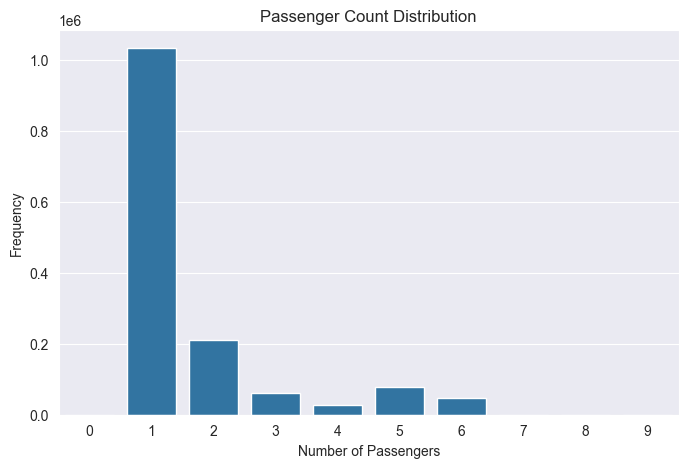

In [29]:
#visualizing data
print("Passenger Count Statistics:")
print(df_new['passenger_count'].describe())

sns.set_style("darkgrid")

passenger_counts = df_new['passenger_count'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.countplot(x='passenger_count', data=df_new)
plt.title("Passenger Count Distribution")
plt.xlabel("Number of Passengers")
plt.ylabel("Frequency");

Vendor ID Statistics:
Count: 1458644
Unique IDs: 2

Value counts per vendor:
vendor_id
2    780302
1    678342
Name: count, dtype: int64

Most frequent vendor: 2


Text(0, 0.5, 'Number of Trips')

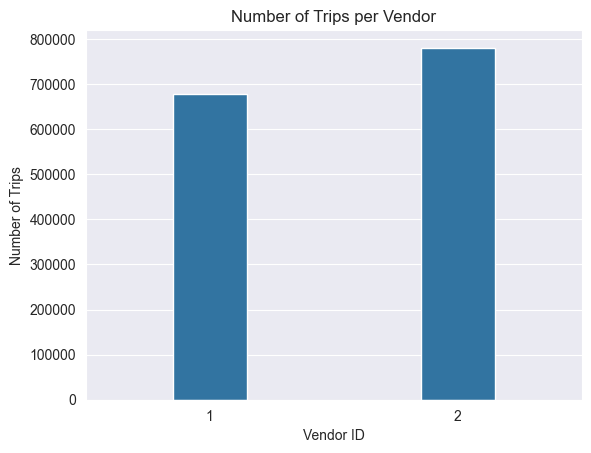

In [30]:
#visualizing data
print("Vendor ID Statistics:")
print("Count:", df_new['vendor_id'].count())
print("Unique IDs:", df_new['vendor_id'].nunique())
print("\nValue counts per vendor:")
print(df_new['vendor_id'].value_counts())

most_freq_vendor = df_new['vendor_id'].mode()[0]
print("\nMost frequent vendor:", most_freq_vendor)

vendor_counts = df_new['vendor_id'].value_counts().sort_index()

plt.figure()
sns.barplot(x=vendor_counts.index, y=vendor_counts.values,width=0.3)
plt.title("Number of Trips per Vendor")
plt.xlabel("Vendor ID")
plt.ylabel("Number of Trips")

Store and Forward Flag Statistics:
Count: 1458644
Unique values: <ArrowStringArray>
['N', 'Y']
Length: 2, dtype: str

Value counts:
store_and_fwd_flag
N    1450599
Y       8045
Name: count, dtype: int64

Percentage of trips per flag:
store_and_fwd_flag
N    99.44846
Y     0.55154
Name: proportion, dtype: float64


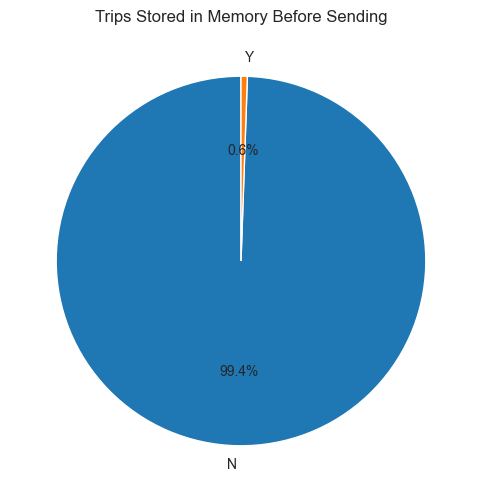

In [31]:
#visualizing data
print("Store and Forward Flag Statistics:")
print("Count:", df_new['store_and_fwd_flag'].count())
print("Unique values:", df_new['store_and_fwd_flag'].unique())
print("\nValue counts:")
flag_counts = df_new['store_and_fwd_flag'].value_counts()
print(flag_counts)


flag_percentage = df_new['store_and_fwd_flag'].value_counts(normalize=True) * 100
print("\nPercentage of trips per flag:")
print(flag_percentage)

plt.figure(figsize=(6,6))
plt.pie(flag_counts.values, labels=flag_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Trips Stored in Memory Before Sending");


Trip Duration Statistics (in seconds):
count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64


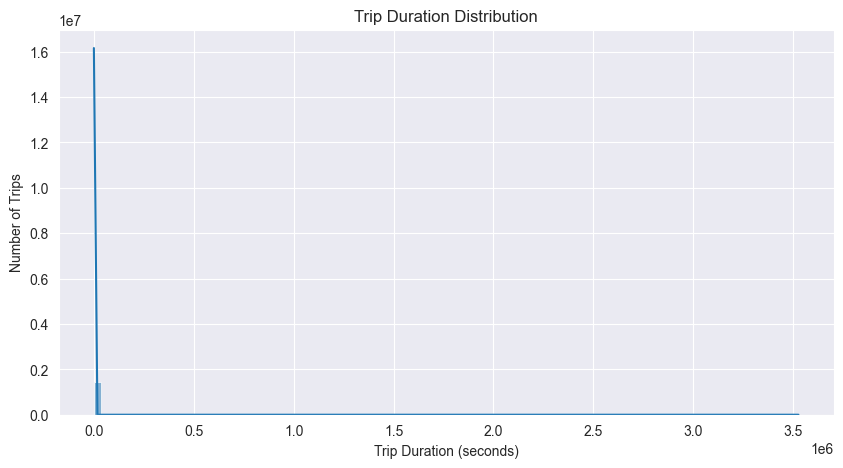

In [32]:
#visualizing data
print("Trip Duration Statistics (in seconds):")
print(df_new['trip_duration'].describe())

# Histogram with distribution curve
plt.figure(figsize=(10,5))
sns.histplot(df_new['trip_duration'], bins=100, kde=True)
plt.title("Trip Duration Distribution")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Number of Trips");

Text(0, 0.5, 'Density')

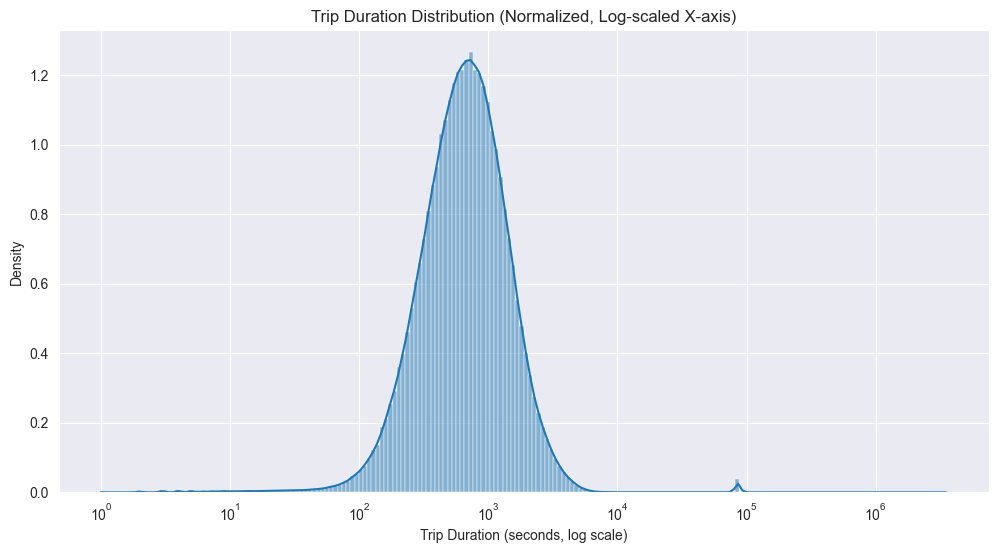

In [33]:
#visualizing data
plt.figure(figsize=(12,6))
sns.histplot(
    df_new['trip_duration'], 
    bins=200, 
    kde=True, 
    stat='density',   # normalize the histogram
    log_scale=(True, False)  # log scale for x-axis only
)

plt.title("Trip Duration Distribution (Normalized, Log-scaled X-axis)")
plt.xlabel("Trip Duration (seconds, log scale)")
plt.ylabel("Density")

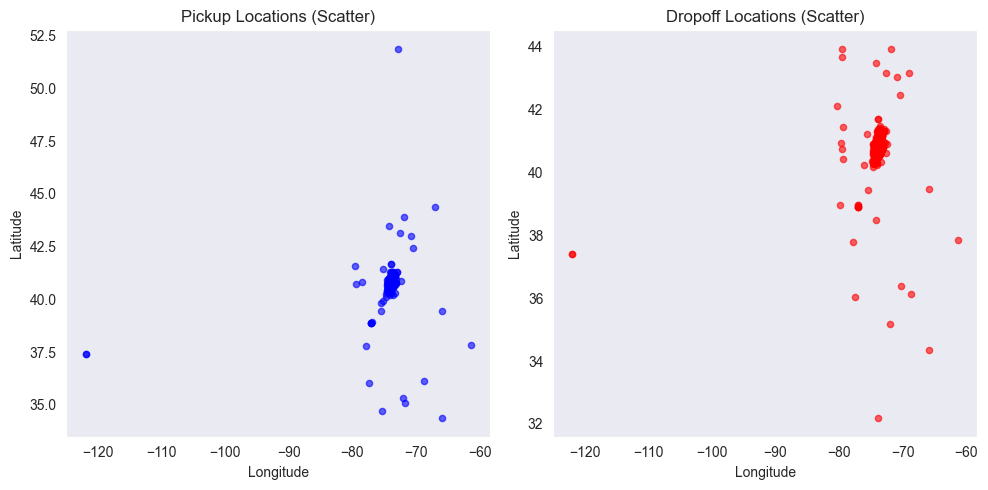

In [34]:
#visualizing data
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.scatter(
    df_new['pickup_longitude'], 
    df_new['pickup_latitude'],
    c='blue',      # solid color
    s=20,           # increased point size
    alpha=0.6      # darker points
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Pickup Locations (Scatter)")
plt.grid(False)


plt.subplot(1, 2, 2)
plt.scatter(
    df_new['dropoff_longitude'], 
    df_new['dropoff_latitude'],
    c='red',       # solid color
    s=20,           # increased point size
    alpha=0.6
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Dropoff Locations (Scatter)")
plt.grid(False)

plt.tight_layout()
plt.show()


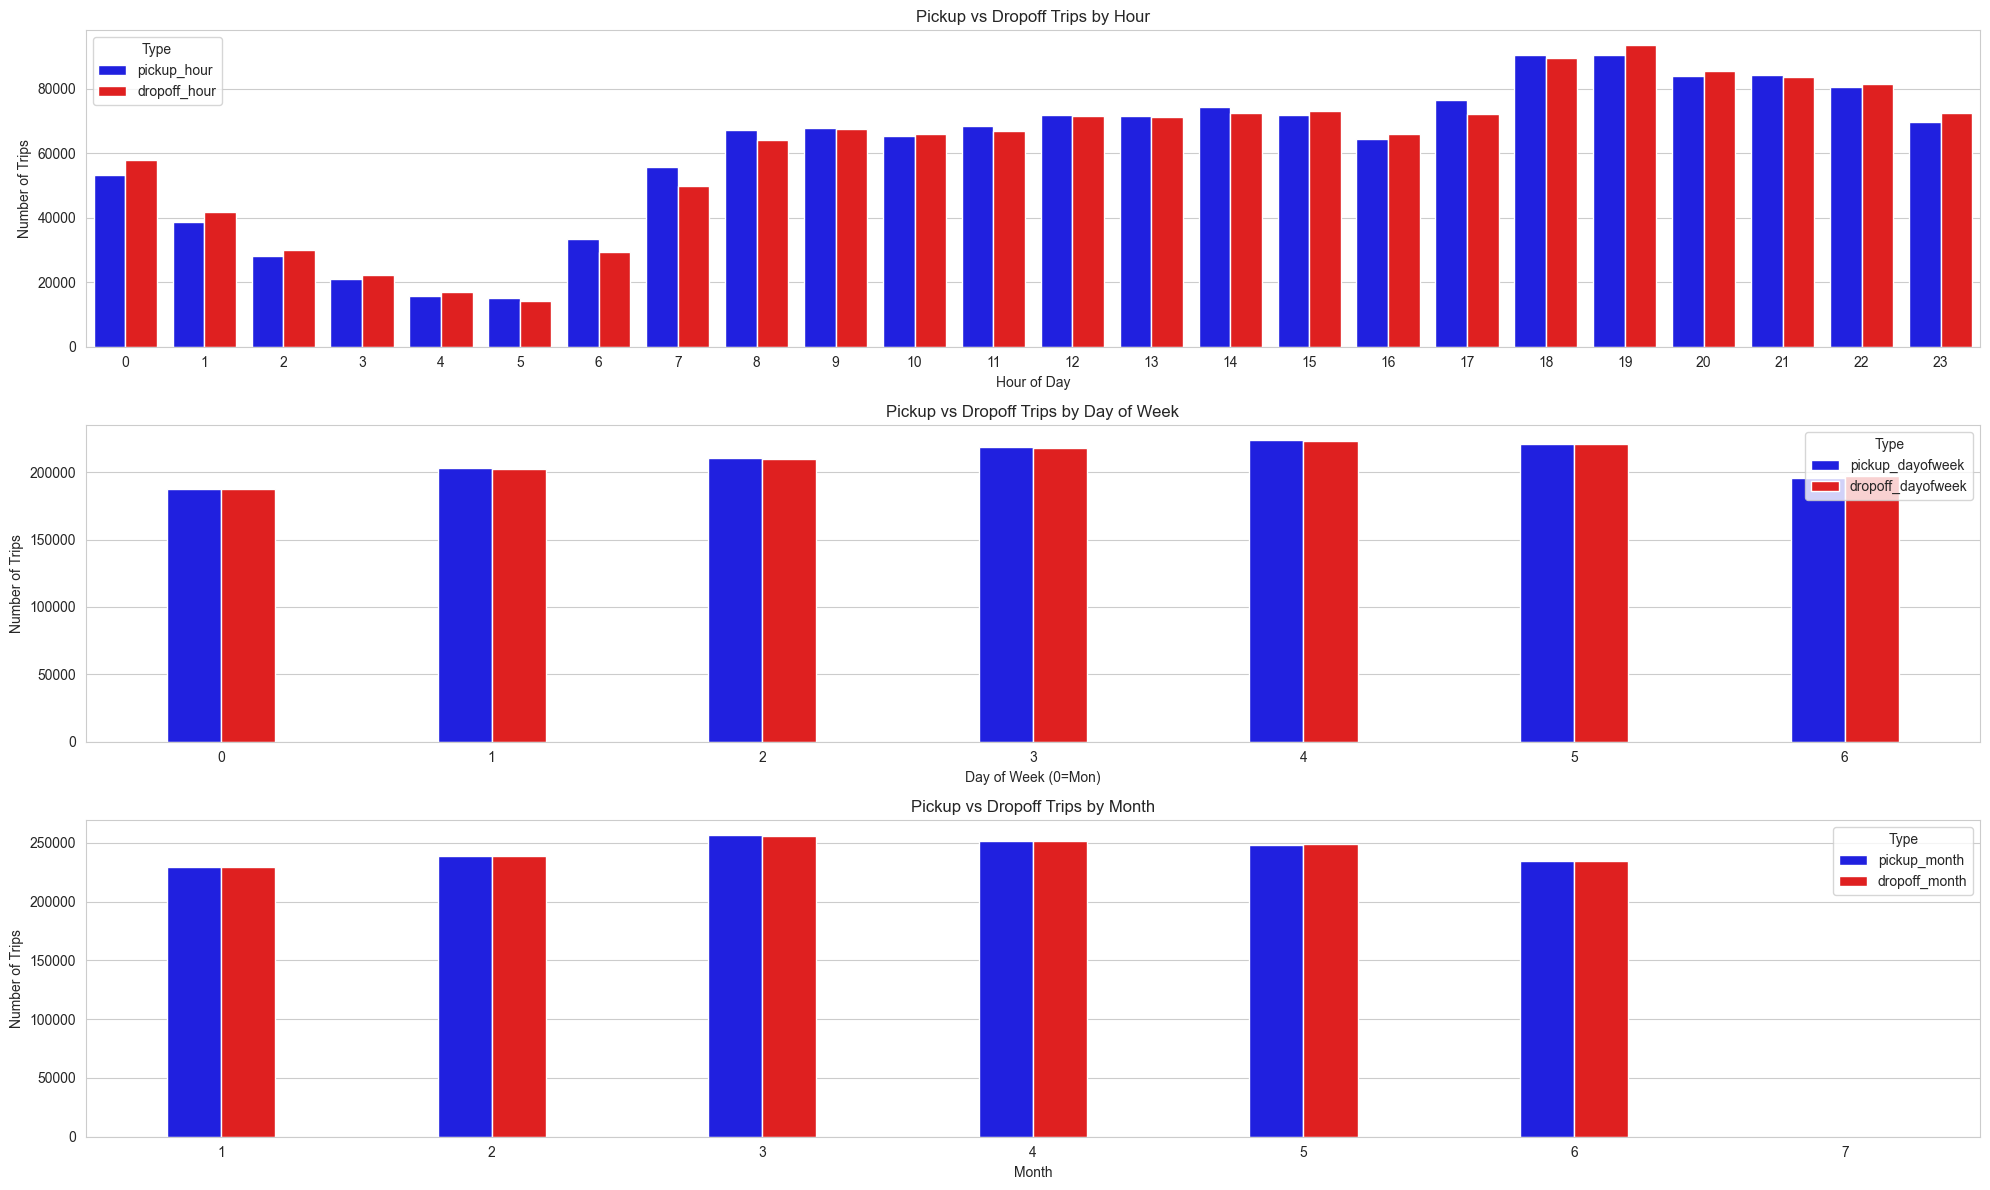

In [35]:
#visualizing data
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

plt.figure(figsize=(20,12))


hour_data = pd.melt(df_new, id_vars=[], value_vars=['pickup_hour', 'dropoff_hour'], 
                    var_name='Type', value_name='Hour')
plt.subplot(3,1,1)
sns.countplot(x='Hour', hue='Type', data=hour_data, palette={'pickup_hour':'blue','dropoff_hour':'red'})
plt.title("Pickup vs Dropoff Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")


dow_data = pd.melt(df_new, id_vars=[], value_vars=['pickup_dayofweek','dropoff_dayofweek'],
                   var_name='Type', value_name='Day')
plt.subplot(3,1,2)
sns.countplot(x='Day', hue='Type', data=dow_data, palette={'pickup_dayofweek':'blue','dropoff_dayofweek':'red'}, width=0.4)
plt.title("Pickup vs Dropoff Trips by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Number of Trips")


month_data = pd.melt(df_new, id_vars=[], value_vars=['pickup_month','dropoff_month'],
                     var_name='Type', value_name='Month')
plt.subplot(3,1,3)
sns.countplot(x='Month', hue='Type', data=month_data, palette={'pickup_month':'blue','dropoff_month':'red'}, width=0.4)
plt.title("Pickup vs Dropoff Trips by Month")
plt.xlabel("Month")
plt.ylabel("Number of Trips")

plt.tight_layout()
plt.show()


# PHASE 2 

In [36]:
weather=pd.read_csv("weather.csv")#reading the weather dataset

In [37]:
weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 366 non-null    str    
 1   maximum temperature  366 non-null    int64  
 2   minimum temperature  366 non-null    int64  
 3   average temperature  366 non-null    float64
 4   precipitation        366 non-null    str    
 5   snow fall            366 non-null    str    
 6   snow depth           366 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 25.4 KB


In [38]:
weather.describe()

,maximum temperature,minimum temperature,average temperature
count,366.000000,366.000000,366.000000
mean,64.625683,49.806011,57.215847
std,18.041787,16.570747,17.124760
min,15.000000,-1.000000,7.000000
25%,50.000000,37.250000,44.000000
50%,64.500000,48.000000,55.750000
75%,81.000000,65.000000,73.500000
max,96.000000,81.000000,88.500000


In [39]:
#checking for duplicates
duplicates = weather.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

print(weather[weather.duplicated()])

Total duplicate rows: 0
Empty DataFrame
Columns: [date, maximum temperature, minimum temperature, average temperature, precipitation, snow fall, snow depth]
Index: []


In [40]:
print(weather.isnull().sum())#checking for null

date                   0
maximum temperature    0
minimum temperature    0
average temperature    0
precipitation          0
snow fall              0
snow depth             0
dtype: int64


In [41]:
# Checking for blank and illegal entries
blanks = (weather.select_dtypes(include=['object', 'string']) == '').sum()
spaces = (weather.select_dtypes(include=['object', 'string']) == ' ').sum()

print("--- Blank String Count ---")
print(blanks + spaces)

--- Blank String Count ---
date             0
precipitation    0
snow fall        0
snow depth       0
dtype: int64


In [42]:
# Checking for missing entries

print("--- Placeholder Values ---")
for col in ['precipitation', 'snow fall', 'snow depth']:
    print(f"{col} contains 'M':", (weather[col] == 'M').sum())
    print(f"{col} contains 'T':", (weather[col] == 'T').sum())

--- Placeholder Values ---
precipitation contains 'M': 0
precipitation contains 'T': 24
snow fall contains 'M': 0
snow fall contains 'T': 15
snow depth contains 'M': 0
snow depth contains 'T': 7


In [43]:
weather['date'] = pd.to_datetime(weather['date'], dayfirst=True)

# Checking the date range
start = weather['date'].min()
end = weather['date'].max()
expected_days = (end - start).days + 1

print(f"Date Range: {start.date()} to {end.date()}")
print(f"Expected number of days: {expected_days}")
print(f"Actual rows in data: {len(weather)}")

Date Range: 2016-01-01 to 2016-12-31
Expected number of days: 366
Actual rows in data: 366


In [44]:
min_pickup = df_new['pickup_date'].min()
max_pickup = df_new['pickup_date'].max()
print(f"Pickup date range: {min_pickup} to {max_pickup}")

# Checking the date range


min_dropoff = df_new['dropoff_date'].min()
max_dropoff = df_new['dropoff_date'].max()
print(f"Dropoff date range: {min_dropoff} to {max_dropoff}")


Pickup date range: 2016-01-01 00:00:00 to 2016-06-30 00:00:00
Dropoff date range: 2016-01-01 00:00:00 to 2016-07-01 00:00:00


In [45]:
date_duplicates = weather['date'].duplicated().sum()
print(date_duplicates)#checking for duplcates

0


In [46]:
df_new.head(5)

,id,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_date,pickup_time,dropoff_date,dropoff_time,pickup_month,pickup_dayofweek,pickup_hour,dropoff_month,dropoff_dayofweek,dropoff_hour
0,id2875421,2,1,-73.982155,40.767937,-73.964630,40.765602,N,455,2016-03-14,17:24:55,2016-03-14,17:32:30,3,0,17,3,0,17
1,id2377394,1,1,-73.980415,40.738564,-73.999481,40.731152,N,663,2016-06-12,00:43:35,2016-06-12,00:54:38,6,6,0,6,6,0
2,id3858529,2,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,2016-01-19,11:35:24,2016-01-19,12:10:48,1,1,11,1,1,12
3,id3504673,2,1,-74.010040,40.719971,-74.012268,40.706718,N,429,2016-04-06,19:32:31,2016-04-06,19:39:40,4,2,19,4,2,19
4,id2181028,2,1,-73.973053,40.793209,-73.972923,40.782520,N,435,2016-03-26,13:30:55,2016-03-26,13:38:10,3,5,13,3,5,13


In [47]:
weather.head(5)

,date,maximum temperature,minimum temperature,average temperature,precipitation,snow fall,snow depth
0,2016-01-01,42,34,38.0,0.00,0.0,0
1,2016-01-02,40,32,36.0,0.00,0.0,0
2,2016-01-03,45,35,40.0,0.00,0.0,0
3,2016-01-04,36,14,25.0,0.00,0.0,0
4,2016-01-05,29,11,20.0,0.00,0.0,0


In [48]:
cols_to_fix = ['precipitation', 'snow fall', 'snow depth']

for col in cols_to_fix:
    # errors='coerce' turns 'T', 'M', or blanks into NaN automatically
    weather[col] = pd.to_numeric(weather[col], errors='coerce')

print("Conversion complete. Non-numeric values have been turned into NaN.")


Conversion complete. Non-numeric values have been turned into NaN.


In [49]:
nan_counts = weather[cols_to_fix].isna().sum()
print("--- Actual NaN Counts ---")
print(nan_counts)

--- Actual NaN Counts ---
precipitation    24
snow fall        15
snow depth        7
dtype: int64


### List of inconsistencies to deal with
* Zero Passenger Trips: 60 records found with passenger count = 0.
* High Occupancy Trips: 5 records found with passenger count > 6
* Ultra-Short Trips: 8,695 trips lasted less than 1 minute.
* Ultra-Long Trips: 4 trips were longer than a day (shortest of these exceeded 22 days).
* Pickup Latitude: 119 trips outside typical NYC range.
* Pickup Longitude: 202 trips outside typical NYC range.
* Dropoff Latitude: 316 trips outside typical NYC range.
* Dropoff Longitude: 805 trips outside typical NYC range.
* Zero Distance: 5,897 trips where pickup coordinates exactly match drop-off coordinates.
* NaN Counts 
    precipitation    24
    snow fall        15
    snow depth        7

In [50]:
# Create a filter for any row that has a NaN in  target columns
missing_weather = weather[
    weather['precipitation'].isna() | 
    weather['snow fall'].isna() | 
    weather['snow depth'].isna()
]

# Sort by date so we can see if they are consecutive
print(f"Total rows with issues: {len(missing_weather)}")
print(missing_weather[['date', 'maximum temperature', 'minimum temperature', 'precipitation', 'snow fall', 'snow depth']])

Total rows with issues: 41
          date  maximum temperature  minimum temperature  precipitation  \
8   2016-01-09                   47                   40            NaN   
11  2016-01-12                   44                   25           0.00   
13  2016-01-14                   38                   22           0.00   
14  2016-01-15                   51                   34            NaN   
17  2016-01-18                   31                   18            NaN   
18  2016-01-19                   28                   16           0.00   
19  2016-01-20                   37                   27           0.00   
23  2016-01-24                   35                   20            NaN   
26  2016-01-27                   47                   34            NaN   
32  2016-02-02                   50                   38           0.00   
34  2016-02-04                   59                   44            NaN   
39  2016-02-09                   36                   27           0.00  

In [51]:
#visualizing the missing pattern 
def plot_nan_indicator(df, col):
    plt.figure(figsize=(12,3))
    
    nan_indicator = df[col].isna().astype(int)
    
    plt.plot(df.index, nan_indicator, drawstyle='steps-mid')
    plt.title(f"Missingness pattern: {col}")
    plt.ylabel("1 = Missing, 0 = Present")
    plt.ylim(-0.1, 1.1)
    plt.show()

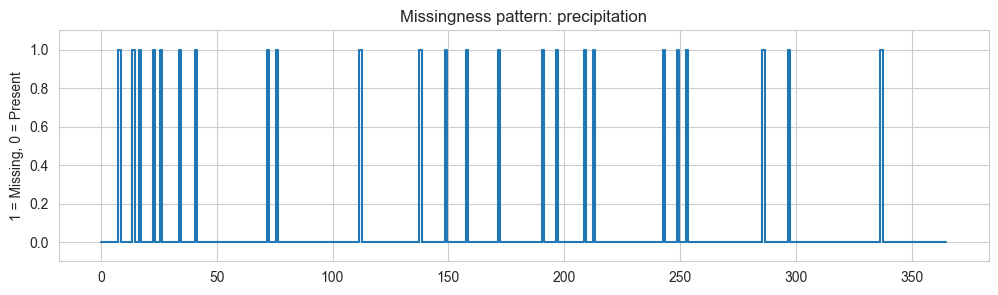

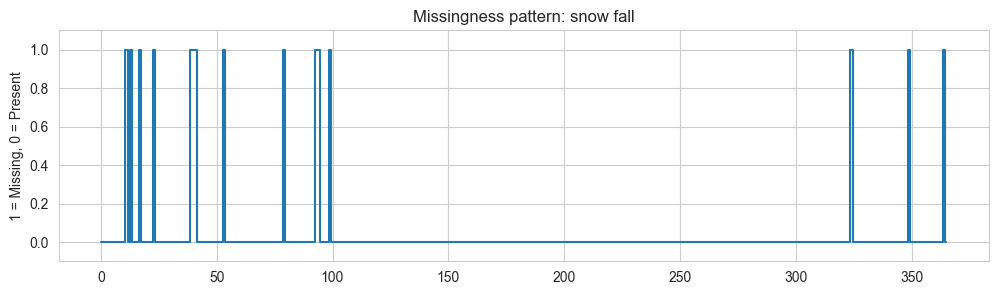

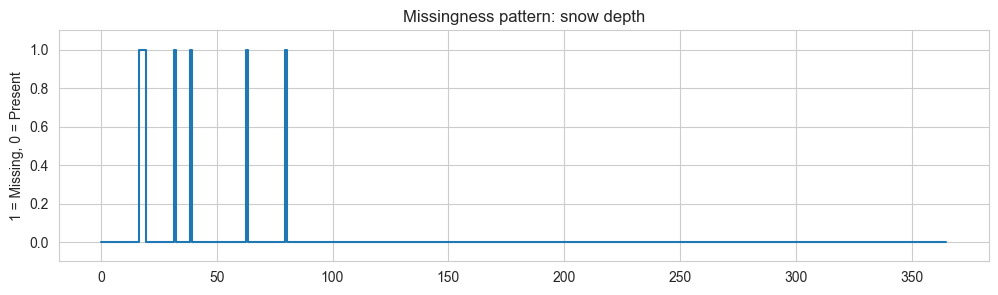

In [52]:
plot_nan_indicator(weather, 'precipitation')
plot_nan_indicator(weather, 'snow fall')
plot_nan_indicator(weather, 'snow depth')

In [53]:
#visualizing the missing pattern 

import matplotlib.pyplot as plt

def clean_line_plot(data, col, title):
    plt.figure(figsize=(25,6))
    
    x = range(len(data))  # 👈 force 0-based index
    
    plt.plot(x, data[col], linewidth=1.5)
    
    plt.title(title)
    plt.xlabel("Day Index (0 → N)")
    plt.ylabel(col)
    
    # grid every 25 days
    plt.xticks(range(0, len(data), 25))
    
    plt.grid(True, alpha=0.3)
    
    plt.show()

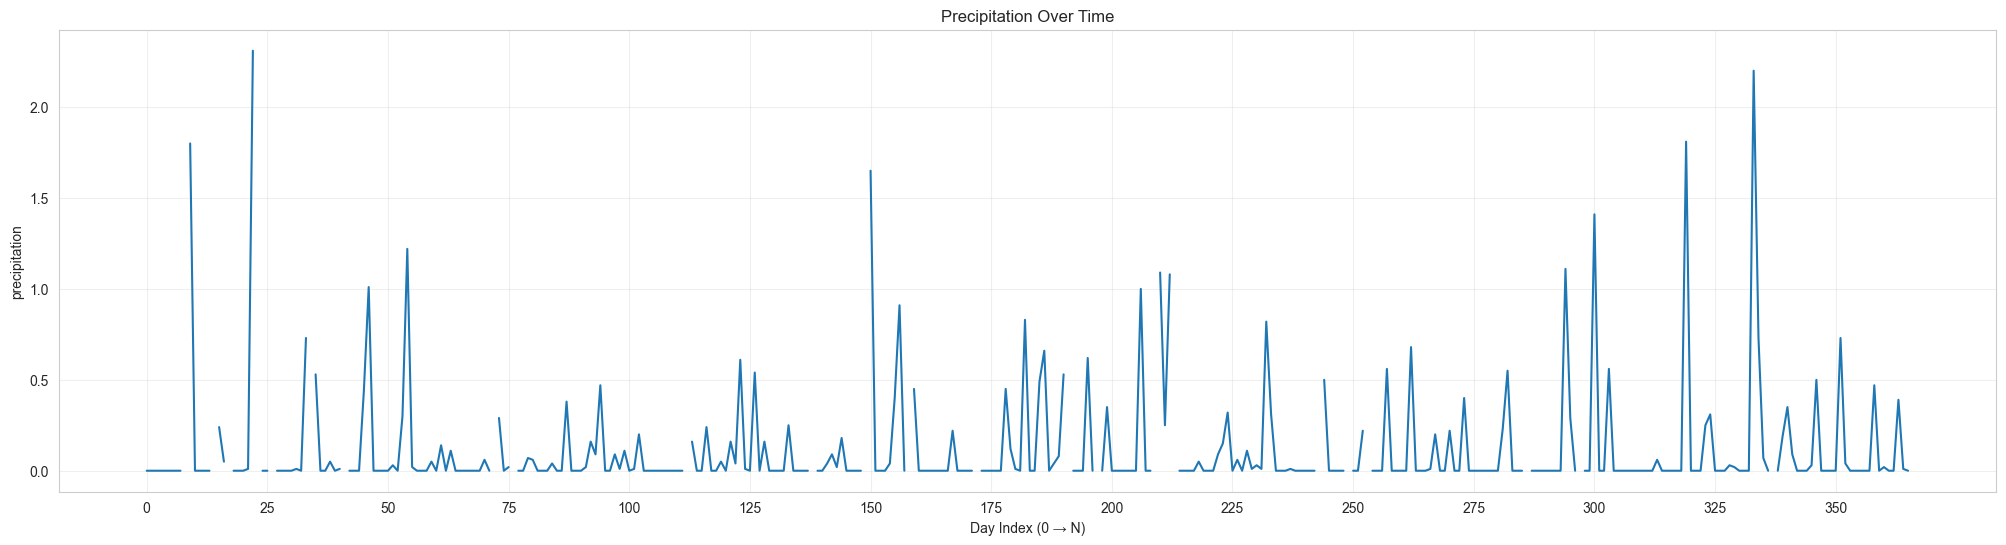

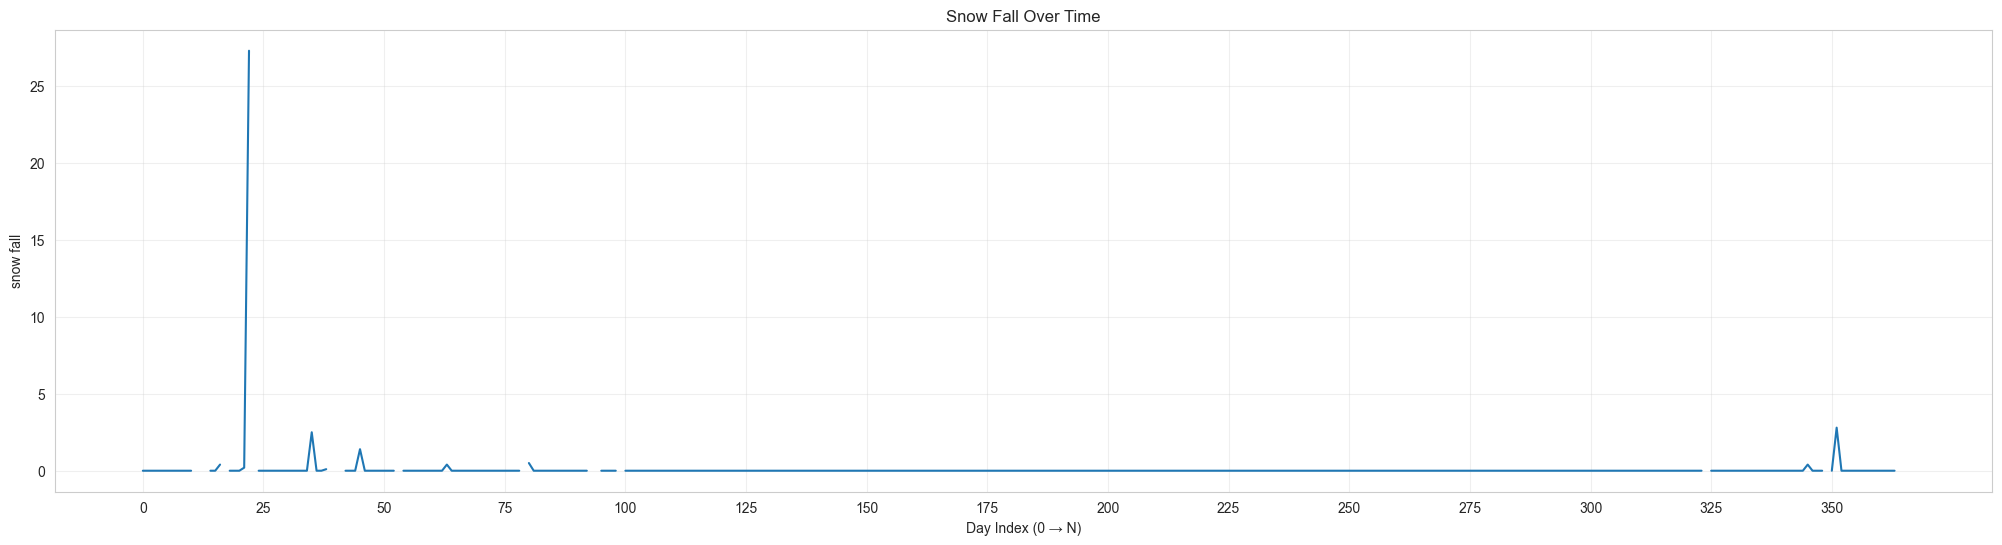

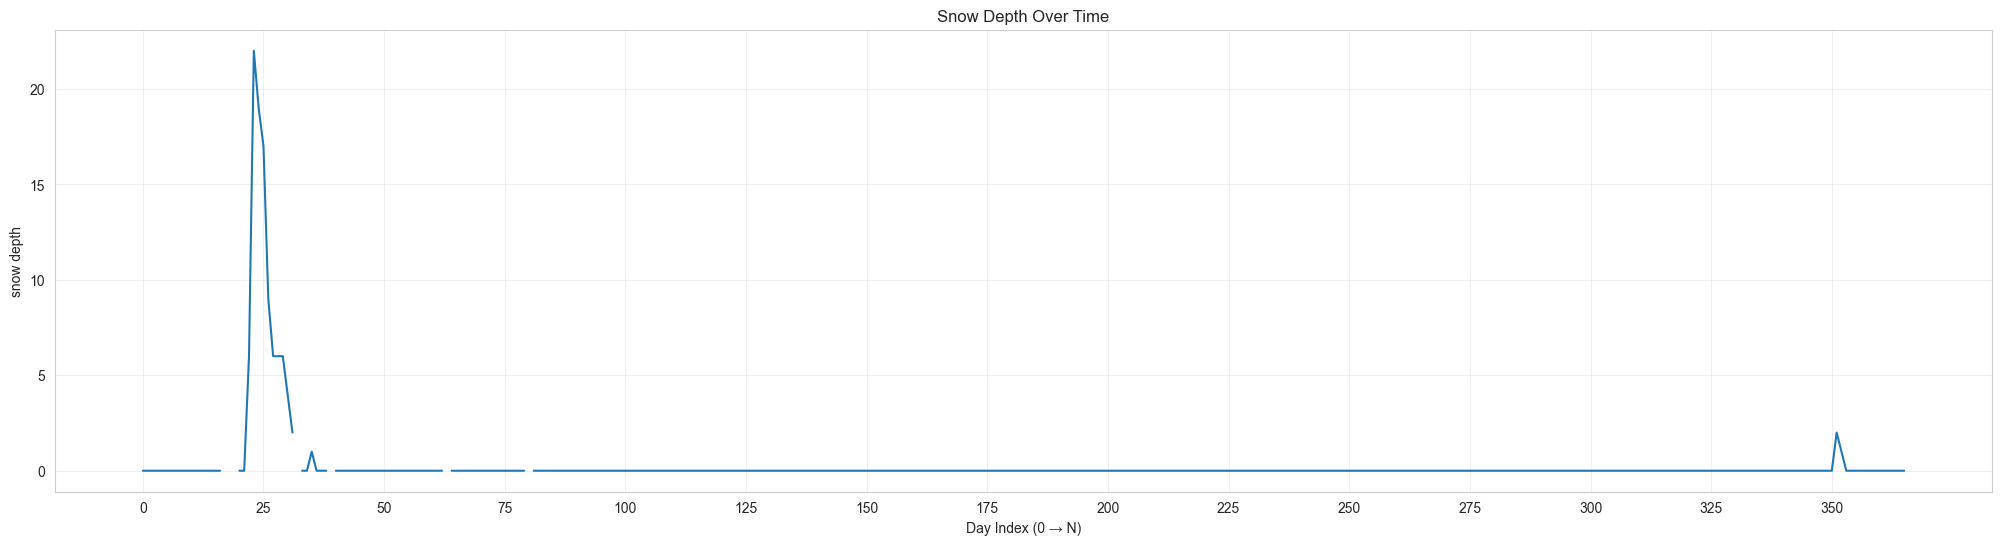

In [54]:
clean_line_plot(weather, 'precipitation', 'Precipitation Over Time')
clean_line_plot(weather, 'snow fall', 'Snow Fall Over Time')
clean_line_plot(weather, 'snow depth', 'Snow Depth Over Time')

In [55]:
#visualizing the missing pattern 

import matplotlib.pyplot as plt

def plot_with_avg_temp(weather, col):
    plt.figure(figsize=(25,6))
    
    x = range(len(weather))
    
    plt.plot(x, weather[col], label=col, linewidth=1.3)
    plt.plot(x, weather['average temperature'], label='Average Temperature', linewidth=1.3)
    
    plt.title(f"{col} vs Average Temperature")
    plt.xlabel("Day Index (0 → N)")
    plt.xticks(range(0, len(weather), 25))
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.show()

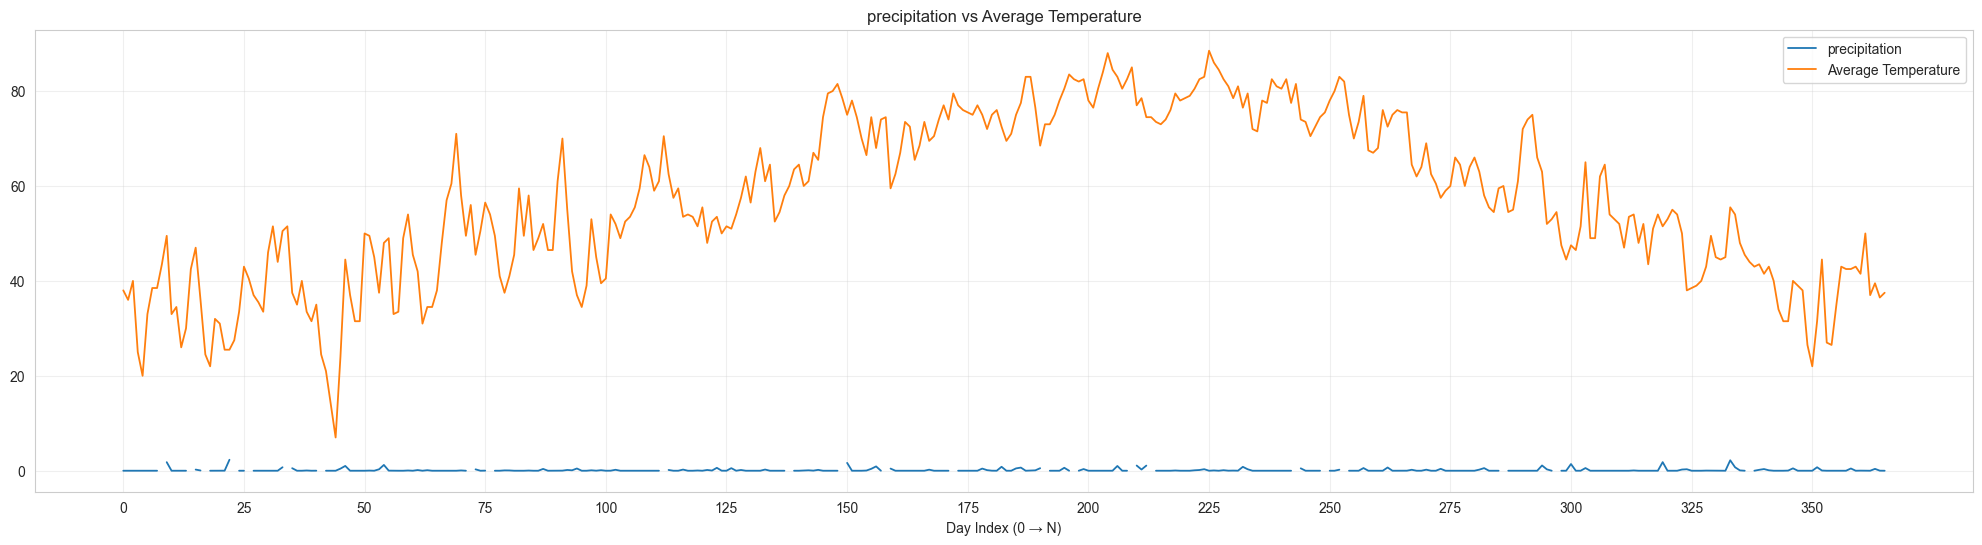

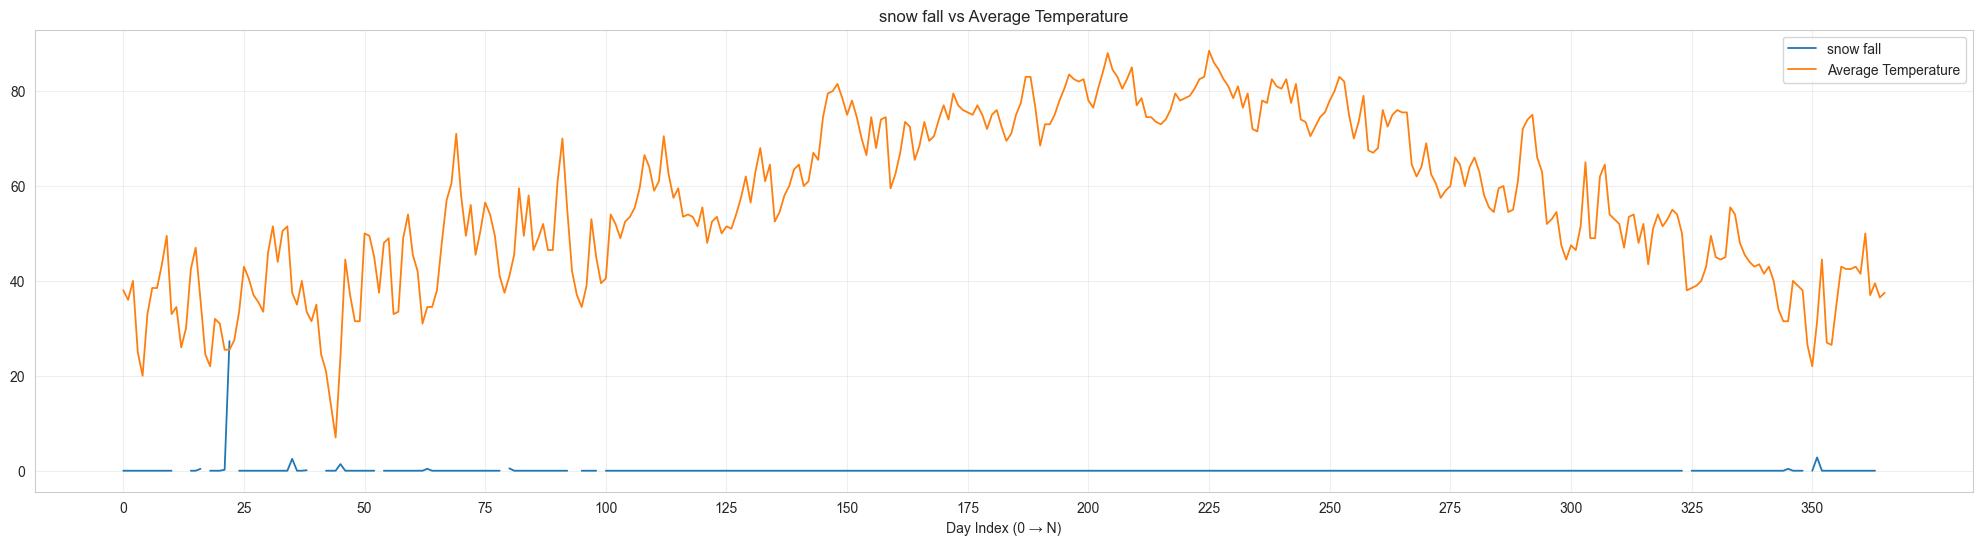

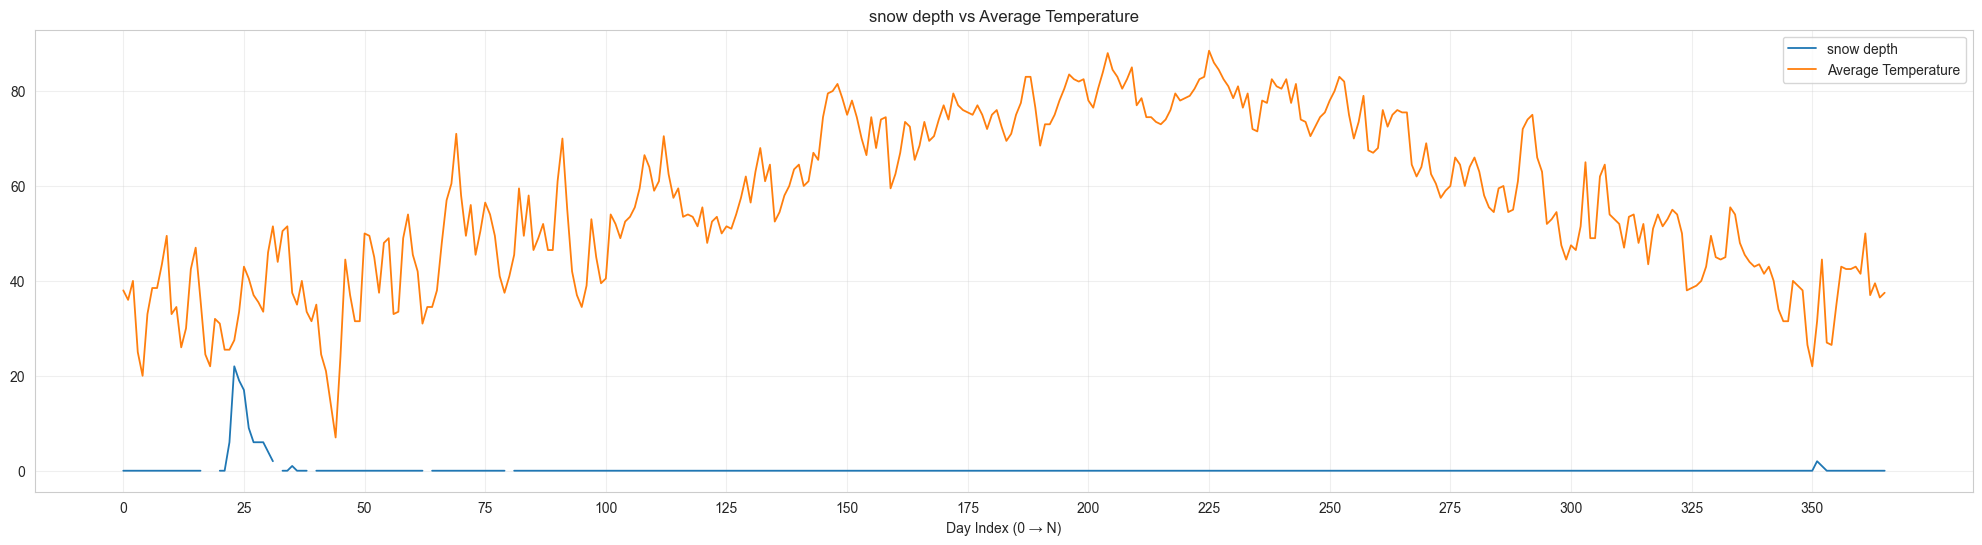

In [56]:
plot_with_avg_temp(weather, 'precipitation')
plot_with_avg_temp(weather, 'snow fall')
plot_with_avg_temp(weather, 'snow depth')

In [57]:
#checking for the type of missing of the data
weather['precip_missing'] = weather['precipitation'].isna().astype(int)

weather.groupby(pd.cut(weather['average temperature'], 5))['precip_missing'].mean()

average temperature
(6.918, 23.3]    0.000000
(23.3, 39.6]     0.050000
(39.6, 55.9]     0.059829
(55.9, 72.2]     0.050000
(72.2, 88.5]     0.097087
Name: precip_missing, dtype: float64

The missingness pattern in precipitation is approximately uniform across most temperature ranges, with only minor variation at higher temperatures. While this suggests that the data is close to MCAR, the slight increase in missingness in warmer ranges indicates a weak dependency on temperature. Therefore, precipitation missingness is best described as near-MCAR (or weak MAR), with no strong evidence of systematic missingness or MNAR behavior.

In [58]:
#checking for the type of missing of the data
weather['snowfall_missing'] = weather['snow fall'].isna().astype(int)

weather.groupby(pd.cut(weather['average temperature'], 5))['snowfall_missing'].mean()

average temperature
(6.918, 23.3]    0.000000
(23.3, 39.6]     0.233333
(39.6, 55.9]     0.008547
(55.9, 72.2]     0.000000
(72.2, 88.5]     0.000000
Name: snowfall_missing, dtype: float64

In [59]:
#checking for the type of missing of the data
weather.groupby('snowfall_missing')['average temperature'].describe()

,count,mean,std,min,25%,50%,75%,max
snowfall_missing,,,,,,,,
0,351.0,58.230769,16.713451,7.0,45.50,58.0,74.0,88.5
1,15.0,33.466667,5.658327,24.5,28.75,35.0,37.5,42.0


In [60]:
#checking for the type of missing of the data
weather.groupby('snowfall_missing')['snow fall'].describe()

,count,mean,std,min,25%,50%,75%,max
snowfall_missing,,,,,,,,
0,351.0,0.102564,1.472052,0.0,0.0,0.0,0.0,27.3
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Snow fall missingness shows a strong dependency on specific temperature ranges, particularly a significant concentration of missing values in the 23.3–39.6°C bin. This clearly violates the MCAR assumption. The structured dependence on observed temperature indicates a Missing At Random (MAR) mechanism, where missingness is influenced by environmental conditions rather than the true snow fall values. There is no evidence supporting MNAR.

In [61]:
#checking for the type of missing of the data
weather['snowdepth_missing'] = weather['snow depth'].isna().astype(int)

weather.groupby(pd.cut(weather['average temperature'], 5))['snowdepth_missing'].mean()

average temperature
(6.918, 23.3]    0.166667
(23.3, 39.6]     0.066667
(39.6, 55.9]     0.017094
(55.9, 72.2]     0.000000
(72.2, 88.5]     0.000000
Name: snowdepth_missing, dtype: float64

In [62]:
#checking for the type of missing of the data
weather.groupby('snowdepth_missing')['average temperature'].describe()

,count,mean,std,min,25%,50%,75%,max
snowdepth_missing,,,,,,,,
0,359.0,57.692201,16.912215,7.0,44.75,57.0,74.00,88.5
1,7.0,32.785714,7.994045,22.0,28.00,32.0,37.75,44.0


In [63]:
#checking for the type of missing of the data
weather.groupby('snowdepth_missing')['snow depth'].describe()

,count,mean,std,min,25%,50%,75%,max
snowdepth_missing,,,,,,,,
0,359.0,0.281337,1.946624,0.0,0.0,0.0,0.0,22.0
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
#checking for the type of missing of the data
weather['extreme_snow'] = weather['snow depth'] > weather['snow depth'].quantile(0.9)
weather['snowdepth_missing'] = weather['snow depth'].isna().astype(int)

In [65]:
weather['prev_extreme'] = weather['extreme_snow'].shift(1)

In [66]:
weather.groupby('prev_extreme')['snowdepth_missing'].mean()

prev_extreme
False    0.017045
True     0.076923
Name: snowdepth_missing, dtype: float64

Snow depth missingness shows a significantly higher probability following extreme snow events, indicating a temporal dependency in the missing data mechanism. This violates the MCAR assumption. However, since the missingness can be explained by observed past values rather than the unobserved current snow depth, there is no evidence supporting MNAR. The missing mechanism is best described as Missing At Random (MAR) with temporal dependence.

In [67]:
weather['date'] = pd.to_datetime(weather['date'])
weather = weather.sort_values('date')
weather = weather.set_index('date')

In [68]:
weather.head(5)

,maximum temperature,minimum temperature,average temperature,precipitation,snow fall,snow depth,precip_missing,snowfall_missing,snowdepth_missing,extreme_snow,prev_extreme
date,,,,,,,,,,,
2016-01-01,42,34,38.0,0.0,0.0,0.0,0,0,0,False,NaN
2016-01-02,40,32,36.0,0.0,0.0,0.0,0,0,0,False,False
2016-01-03,45,35,40.0,0.0,0.0,0.0,0,0,0,False,False
2016-01-04,36,14,25.0,0.0,0.0,0.0,0,0,0,False,False
2016-01-05,29,11,20.0,0.0,0.0,0.0,0,0,0,False,False


In [69]:
# ensure time index
weather.index = pd.to_datetime(weather.index)
weather = weather.sort_index()

# interpolate ONLY numeric columns
num_cols = weather.select_dtypes(include=['number']).columns
weather[num_cols] = weather[num_cols].interpolate(method='time', limit_direction='both')

# fill remaining edges
weather[num_cols] = weather[num_cols].ffill().bfill()

In [70]:
weather.isna().sum()

maximum temperature    0
minimum temperature    0
average temperature    0
precipitation          0
snow fall              0
snow depth             0
precip_missing         0
snowfall_missing       0
snowdepth_missing      0
extreme_snow           0
prev_extreme           1
dtype: int64

In [71]:
weather = weather.drop(columns=[
    'precip_missing',
    'snowfall_missing',
    'snowdepth_missing',
    'extreme_snow',
    'prev_extreme'
])#deleting the unecessary columns

In [72]:
weather.head(5)

,maximum temperature,minimum temperature,average temperature,precipitation,snow fall,snow depth
date,,,,,,
2016-01-01,42,34,38.0,0.0,0.0,0.0
2016-01-02,40,32,36.0,0.0,0.0,0.0
2016-01-03,45,35,40.0,0.0,0.0,0.0
2016-01-04,36,14,25.0,0.0,0.0,0.0
2016-01-05,29,11,20.0,0.0,0.0,0.0


In [73]:
weather.describe()

,maximum temperature,minimum temperature,average temperature,precipitation,snow fall,snow depth
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,64.625683,49.806011,57.215847,0.131148,0.137295,0.278689
std,18.041787,16.570747,17.124760,0.321028,1.606199,1.928569
min,15.000000,-1.000000,7.000000,0.000000,0.000000,0.000000
25%,50.000000,37.250000,44.000000,0.000000,0.000000,0.000000
50%,64.500000,48.000000,55.750000,0.000000,0.000000,0.000000
75%,81.000000,65.000000,73.500000,0.067500,0.000000,0.000000
max,96.000000,81.000000,88.500000,2.310000,27.300000,22.000000


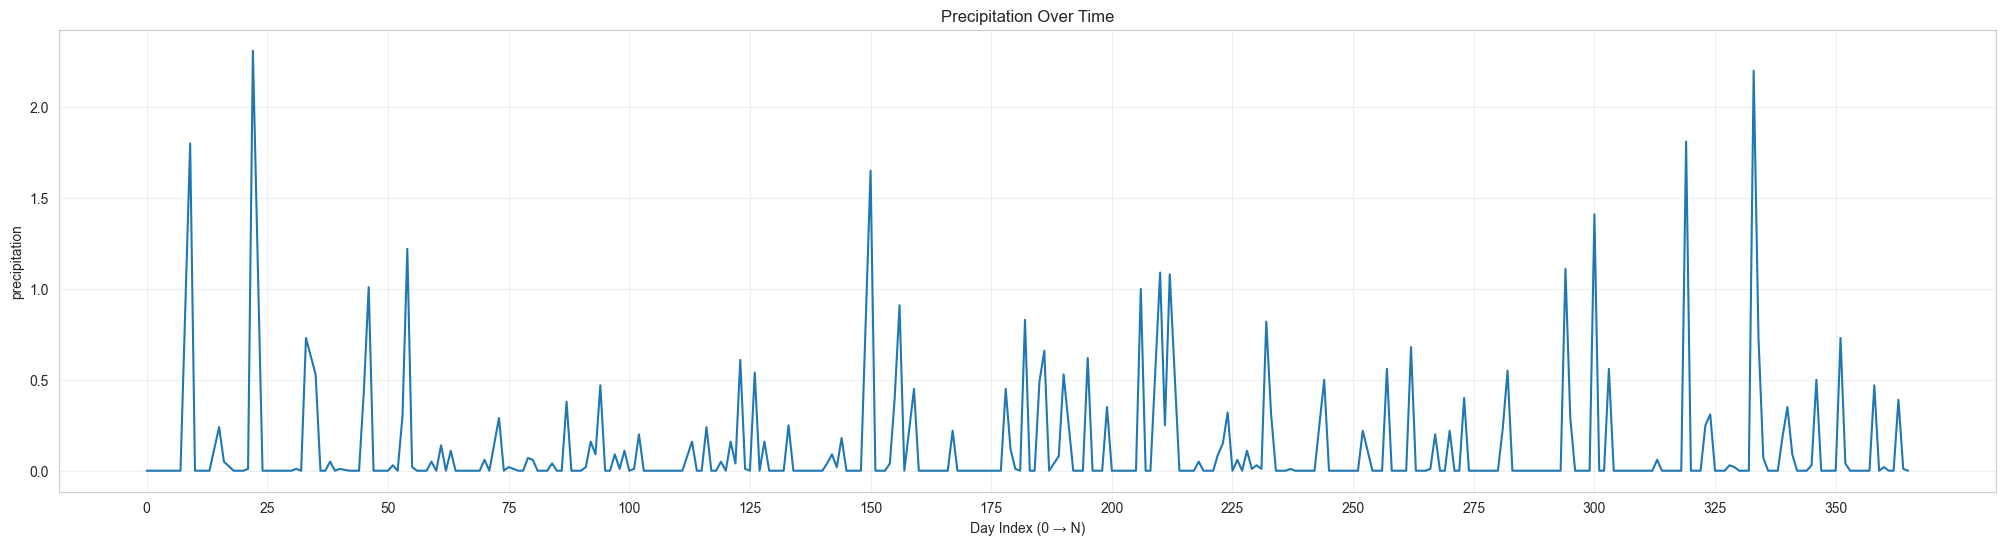

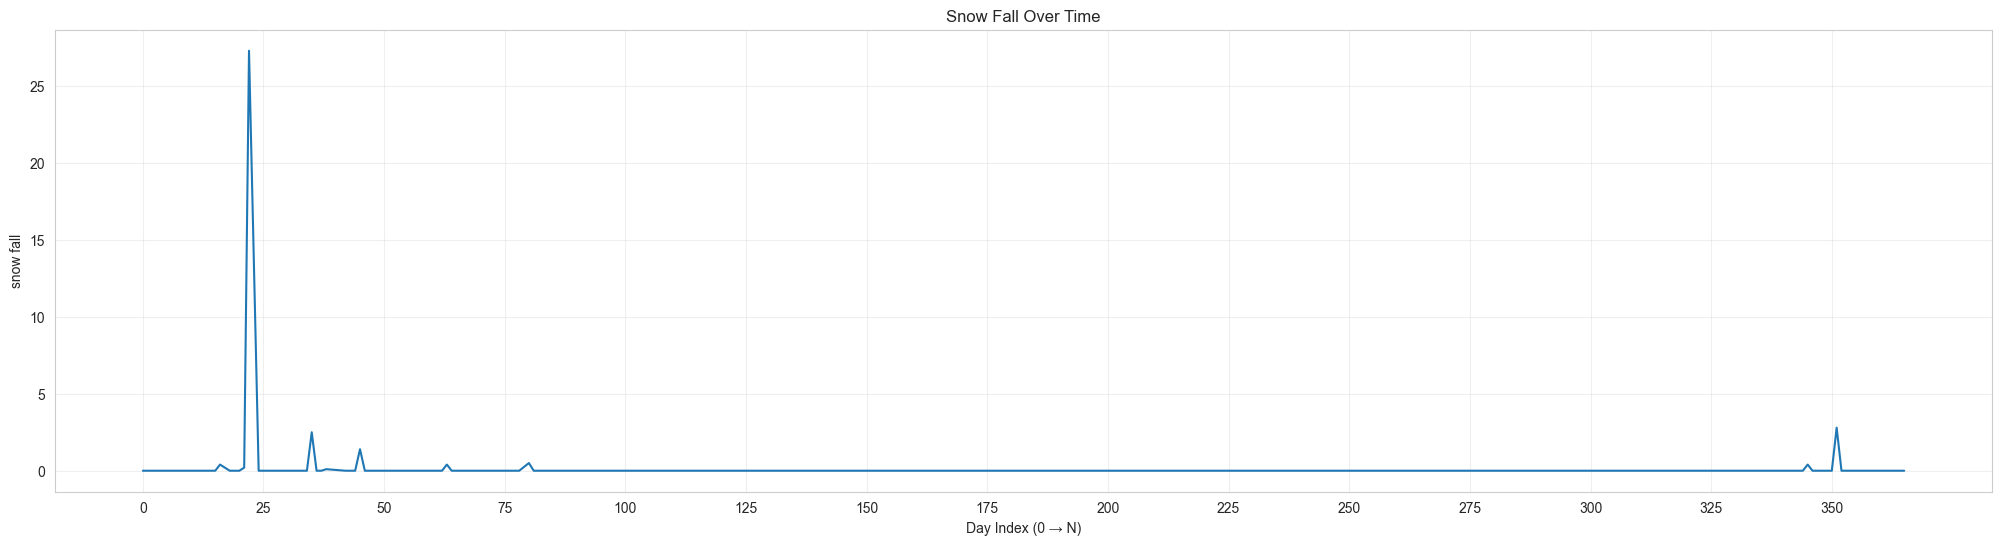

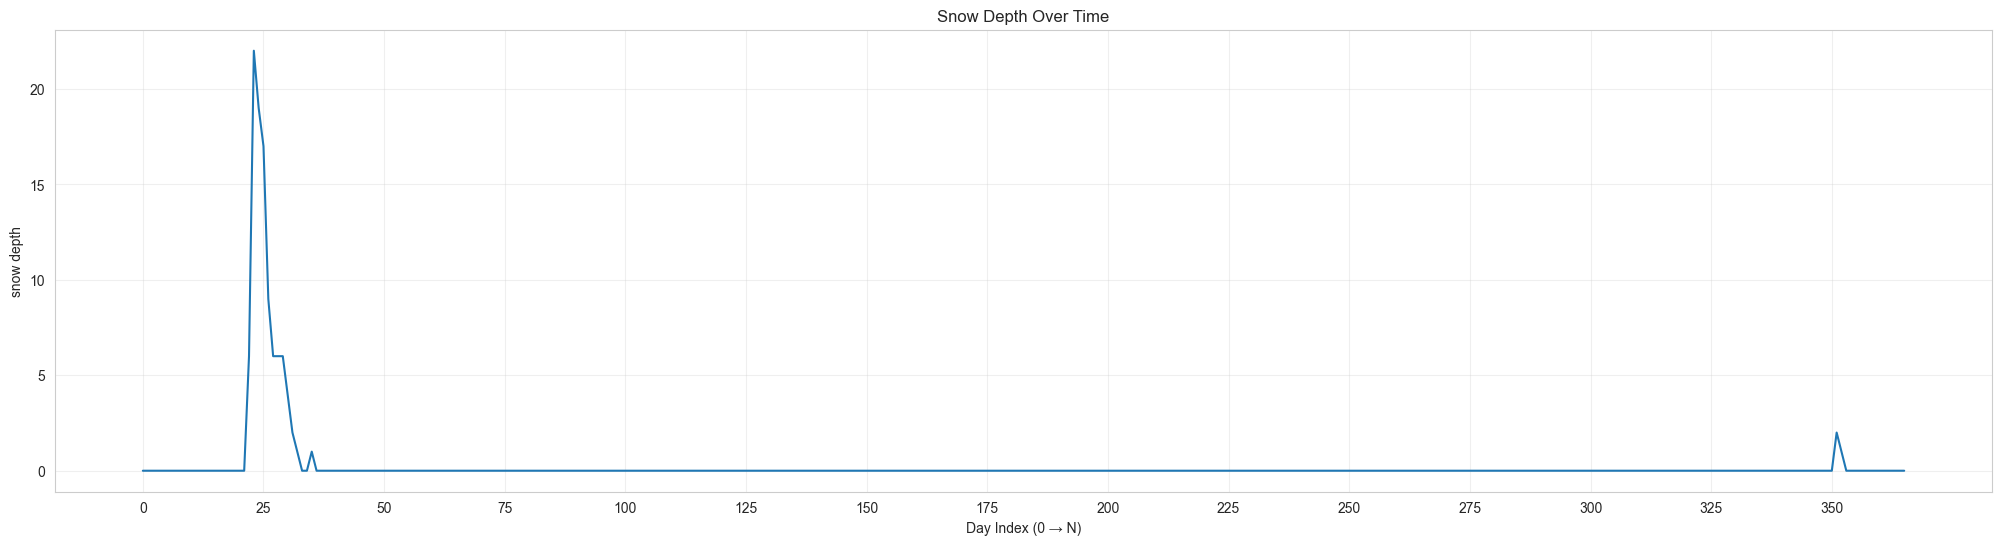

In [74]:
#visualing the data after dealing with missing values
clean_line_plot(weather, 'precipitation', 'Precipitation Over Time')
clean_line_plot(weather, 'snow fall', 'Snow Fall Over Time')
clean_line_plot(weather, 'snow depth', 'Snow Depth Over Time')

In [75]:
weather = weather.reset_index()


In [76]:
weather = weather.drop(columns=['level_0', 'index'], errors='ignore')


In [77]:
weather = weather.sort_values('date')
weather.to_csv("weather_cleaned.csv", index=False)

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 15 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  str           
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[us]
 3   dropoff_datetime    1458644 non-null  datetime64[us]
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  str           
 10  trip_duration       1458644 non-null  int64         
 11  pickup_date         1458644 non-null  object        
 12  pickup_time         1458644 non-null  object        
 13  dropoff_date        145

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 15 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  str           
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[us]
 3   dropoff_datetime    1458644 non-null  datetime64[us]
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  str           
 10  trip_duration       1458644 non-null  int64         
 11  pickup_date         1458644 non-null  object        
 12  pickup_time         1458644 non-null  object        
 13  dropoff_date        145

In [80]:
import pandas as pd

# -----------------------------
# 1. Ensure numeric types
# -----------------------------
df['passenger_count'] = pd.to_numeric(df['passenger_count'], errors='coerce')
df['trip_duration'] = pd.to_numeric(df['trip_duration'], errors='coerce')

# -----------------------------
# 2. Drop missing values in key columns
# -----------------------------
df = df.dropna(subset=['passenger_count', 'trip_duration'])

# -----------------------------
# 3. Remove invalid passenger counts
# -----------------------------
df = df[df['passenger_count'] > 0]

# -----------------------------
# 4. Remove ultra-short trips (< 60 sec)
# -----------------------------
df = df[df['trip_duration'] >= 60]

# -----------------------------
# 5. Remove ultra-long trips (> 1 day)
# -----------------------------
df = df[df['trip_duration'] <= 86400]

# -----------------------------
# 6. Keep only valid NYC coordinates
# -----------------------------
lat_min, lat_max = 40.5, 41.0
lon_min, lon_max = -74.3, -73.7

df = df[
    df['pickup_latitude'].between(lat_min, lat_max) &
    df['dropoff_latitude'].between(lat_min, lat_max) &
    df['pickup_longitude'].between(lon_min, lon_max) &
    df['dropoff_longitude'].between(lon_min, lon_max)
]

# -----------------------------
# 7. Remove ONLY suspicious same-location short trips
# -----------------------------
df = df[~(
    (df['pickup_latitude'] == df['dropoff_latitude']) &
    (df['pickup_longitude'] == df['dropoff_longitude']) &
    (df['trip_duration'] < 1800)
)]

# -----------------------------
# 8. Reset index
# -----------------------------
df = df.reset_index(drop=True)

The dataset was preprocessed to remove inconsistent and physically unrealistic records while preserving valid real-world taxi behavior. All key numerical columns, including passenger count, trip duration, and trip distance, were first converted to numeric types, and records with missing values in these fields were removed.

Trips with zero passengers were excluded as they are not valid in real-world scenarios. Extremely short trips lasting less than 60 seconds were removed as they are likely due to GPS noise, recording errors, or cancelled rides. Similarly, extremely long trips exceeding 24 hours (86,400 seconds) were removed as they are considered implausible or corrupted entries.

To ensure spatial validity, all pickup and dropoff coordinates were filtered to remain within a realistic geographic boundary of New York City (latitude: 40.5–41.0, longitude: -74.3–-73.7). This step eliminated trips with incorrect or noisy GPS locations.

Additionally, zero-distance trips (where pickup and dropoff locations are identical) were treated carefully. Only those with very short durations (< 30 minutes) were removed, as they are likely data errors or incomplete records, while longer zero-distance trips were retained as they may represent valid edge cases such as waiting time or booking anomalies.

Passenger counts greater than 6 were not removed, since such values can still be realistic in certain cases (e.g., larger vehicles such as vans or group transport). These were retained to avoid introducing unnecessary bias into the dataset.

Finally, the dataset index was reset to ensure consistency after filtering. This preprocessing step ensures that the dataset is clean, consistent, and suitable for machine learning models.

In [81]:
df.shape

(1445172, 15)

In [82]:
df.describe()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.445172e+06,1445172,1445172,1.445172e+06,1.445172e+06,1.445172e+06,1.445172e+06,1.445172e+06,1.445172e+06
mean,1.535056e+00,2016-04-01 10:05:08.013925,2016-04-01 10:21:06.208961,1.665517e+00,-7.397366e+01,4.075101e+01,-7.397364e+01,4.075186e+01,9.581950e+02
min,1.000000e+00,2016-01-01 00:00:17,2016-01-01 00:03:31,1.000000e+00,-7.428902e+01,4.050629e+01,-7.429299e+01,4.050860e+01,6.000000e+01
25%,1.000000e+00,2016-02-17 16:50:23.500000,2016-02-17 17:09:00,1.000000e+00,-7.399188e+01,4.073743e+01,-7.399133e+01,4.073596e+01,4.020000e+02
50%,2.000000e+00,2016-04-01 17:01:24.500000,2016-04-01 17:20:53.500000,1.000000e+00,-7.398178e+01,4.075414e+01,-7.397979e+01,4.075456e+01,6.660000e+02
75%,2.000000e+00,2016-05-15 03:33:43,2016-05-15 03:48:06.750000,2.000000e+00,-7.396750e+01,4.076836e+01,-7.396317e+01,4.076981e+01,1.079000e+03
max,2.000000e+00,2016-06-30 23:59:39,2016-07-01 23:02:03,8.000000e+00,-7.370805e+01,4.099752e+01,-7.370030e+01,4.099984e+01,8.639200e+04
std,4.987697e-01,NaN,NaN,1.314763e+00,3.762766e-02,2.780548e-02,3.459604e-02,3.194298e-02,3.182206e+03


In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1445172 entries, 0 to 1445171
Data columns (total 15 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1445172 non-null  str           
 1   vendor_id           1445172 non-null  int64         
 2   pickup_datetime     1445172 non-null  datetime64[us]
 3   dropoff_datetime    1445172 non-null  datetime64[us]
 4   passenger_count     1445172 non-null  int64         
 5   pickup_longitude    1445172 non-null  float64       
 6   pickup_latitude     1445172 non-null  float64       
 7   dropoff_longitude   1445172 non-null  float64       
 8   dropoff_latitude    1445172 non-null  float64       
 9   store_and_fwd_flag  1445172 non-null  str           
 10  trip_duration       1445172 non-null  int64         
 11  pickup_date         1445172 non-null  object        
 12  pickup_time         1445172 non-null  object        
 13  dropoff_date        144

In [84]:
df.to_csv("cleaned_taxi_data.csv", index=False)

In [85]:
import pandas as pd

# -----------------------------
# 1. Convert to datetime
# -----------------------------
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

# -----------------------------
# 2. BASIC TIME FEATURES (Pickup)
# -----------------------------
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_day_of_week'] = df['pickup_datetime'].dt.dayofweek

# -----------------------------
# 3. BASIC TIME FEATURES (Dropoff)
# -----------------------------
df['dropoff_hour'] = df['dropoff_datetime'].dt.hour
df['dropoff_day'] = df['dropoff_datetime'].dt.day
df['dropoff_month'] = df['dropoff_datetime'].dt.month
df['dropoff_day_of_week'] = df['dropoff_datetime'].dt.dayofweek

# -----------------------------
# 4. LABELS (Human readable)
# -----------------------------
day_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

df['pickup_day_name'] = df['pickup_day_of_week'].map(day_map)
df['dropoff_day_name'] = df['dropoff_day_of_week'].map(day_map)


In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1445172 entries, 0 to 1445171
Data columns (total 25 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   id                   1445172 non-null  str           
 1   vendor_id            1445172 non-null  int64         
 2   pickup_datetime      1445172 non-null  datetime64[us]
 3   dropoff_datetime     1445172 non-null  datetime64[us]
 4   passenger_count      1445172 non-null  int64         
 5   pickup_longitude     1445172 non-null  float64       
 6   pickup_latitude      1445172 non-null  float64       
 7   dropoff_longitude    1445172 non-null  float64       
 8   dropoff_latitude     1445172 non-null  float64       
 9   store_and_fwd_flag   1445172 non-null  str           
 10  trip_duration        1445172 non-null  int64         
 11  pickup_date          1445172 non-null  object        
 12  pickup_time          1445172 non-null  object        
 13  dropoff_

In [87]:
df.head(1)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,pickup_hour,pickup_day,pickup_month,pickup_day_of_week,dropoff_hour,dropoff_day,dropoff_month,dropoff_day_of_week,pickup_day_name,dropoff_day_name
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.96463,40.765602,N,...,17,14,3,0,17,14,3,0,Monday,Monday


In [88]:
#Adding the time labels
def time_label(hour):
    if 0 <= hour < 5:
        return "Night"
    elif 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Late Night"

df['pickup_time_label'] = df['pickup_hour'].apply(time_label)
df['dropoff_time_label'] = df['dropoff_hour'].apply(time_label)

In [89]:
#adding new features
df['is_weekend'] = df['pickup_day_of_week'].isin([5, 6]).astype(int)
df['cross_day_trip'] = (df['pickup_day'] != df['dropoff_day']).astype(int)

In [90]:
df.head(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,dropoff_hour,dropoff_day,dropoff_month,dropoff_day_of_week,pickup_day_name,dropoff_day_name,pickup_time_label,dropoff_time_label,is_weekend,cross_day_trip
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,17,14,3,0,Monday,Monday,Evening,Evening,0,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,0,12,6,6,Sunday,Sunday,Night,Night,1,0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,12,19,1,1,Tuesday,Tuesday,Morning,Afternoon,0,0


Temporal features were extracted from both the pickup and dropoff timestamps to capture time-based patterns in taxi trips. The datetime columns were first converted into proper pandas datetime format to enable structured feature extraction.

From both pickup and dropoff timestamps, key features such as hour, day of the month, month, and day of the week were derived. Additionally, human-readable weekday labels (e.g., Monday, Tuesday, etc.) were created to improve interpretability.

To capture daily behavioral patterns, time-of-day categorical labels were also generated based on the hour of travel. These labels divide the day into meaningful segments such as Night, Morning, Afternoon, Evening, and Late Night, allowing better understanding of demand variations across different periods of the day.Additional columns were added to indicate if it is the weekend or a weekday along with a cross say trip indicator for additional information.

These engineered features enable the analysis of temporal trends in taxi usage and provide important inputs for downstream machine learning models.

In [91]:
df['pickup_date'] = df['pickup_datetime'].dt.date
df['dropoff_date'] = df['dropoff_datetime'].dt.date

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1445172 entries, 0 to 1445171
Data columns (total 29 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   id                   1445172 non-null  str           
 1   vendor_id            1445172 non-null  int64         
 2   pickup_datetime      1445172 non-null  datetime64[us]
 3   dropoff_datetime     1445172 non-null  datetime64[us]
 4   passenger_count      1445172 non-null  int64         
 5   pickup_longitude     1445172 non-null  float64       
 6   pickup_latitude      1445172 non-null  float64       
 7   dropoff_longitude    1445172 non-null  float64       
 8   dropoff_latitude     1445172 non-null  float64       
 9   store_and_fwd_flag   1445172 non-null  str           
 10  trip_duration        1445172 non-null  int64         
 11  pickup_date          1445172 non-null  object        
 12  pickup_time          1445172 non-null  object        
 13  dropoff_

In [93]:
df['pickup_date'] = pd.to_datetime(df['pickup_date'])
df['dropoff_date'] = pd.to_datetime(df['dropoff_date'])

weather['date'] = pd.to_datetime(weather['date'])

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1445172 entries, 0 to 1445171
Data columns (total 29 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   id                   1445172 non-null  str           
 1   vendor_id            1445172 non-null  int64         
 2   pickup_datetime      1445172 non-null  datetime64[us]
 3   dropoff_datetime     1445172 non-null  datetime64[us]
 4   passenger_count      1445172 non-null  int64         
 5   pickup_longitude     1445172 non-null  float64       
 6   pickup_latitude      1445172 non-null  float64       
 7   dropoff_longitude    1445172 non-null  float64       
 8   dropoff_latitude     1445172 non-null  float64       
 9   store_and_fwd_flag   1445172 non-null  str           
 10  trip_duration        1445172 non-null  int64         
 11  pickup_date          1445172 non-null  datetime64[s] 
 12  pickup_time          1445172 non-null  object        
 13  dropoff_

In [95]:
weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 366 non-null    datetime64[us]
 1   maximum temperature  366 non-null    int64         
 2   minimum temperature  366 non-null    int64         
 3   average temperature  366 non-null    float64       
 4   precipitation        366 non-null    float64       
 5   snow fall            366 non-null    float64       
 6   snow depth           366 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(2)
memory usage: 20.1 KB


In [96]:
import pandas as pd

# -----------------------------
# 1. CLEAN WEATHER COLUMN NAMES
# -----------------------------
weather.columns = weather.columns.str.strip().str.replace(" ", "_")

# -----------------------------
# 2. FIX DATES (ON df, NOT df_new)
# -----------------------------
df['pickup_date'] = pd.to_datetime(df['pickup_date']).dt.normalize()
df['dropoff_date'] = pd.to_datetime(df['dropoff_date']).dt.normalize()
weather['date'] = pd.to_datetime(weather['date']).dt.normalize()

# -----------------------------
# 3. CREATE WEATHER COPIES
# -----------------------------
weather_pickup = weather.copy()
weather_pickup.columns = [
    'p_' + col if col != 'date' else 'p_date'
    for col in weather.columns
]

weather_dropoff = weather.copy()
weather_dropoff.columns = [
    'd_' + col if col != 'date' else 'd_date'
    for col in weather.columns
]

# -----------------------------
# 4. MERGE
# -----------------------------
master_df = df.copy()

master_df = master_df.merge(
    weather_pickup,
    left_on='pickup_date',
    right_on='p_date',
    how='left'
)

master_df = master_df.merge(
    weather_dropoff,
    left_on='dropoff_date',
    right_on='d_date',
    how='left'
)

# -----------------------------
# 5. DROP EXTRA KEYS
# -----------------------------
master_df.drop(columns=['p_date', 'd_date'], inplace=True)

# -----------------------------
# 6. CHECK
# -----------------------------
print(master_df.columns)
master_df.info()

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_date', 'pickup_time', 'dropoff_date',
       'dropoff_time', 'pickup_hour', 'pickup_day', 'pickup_month',
       'pickup_day_of_week', 'dropoff_hour', 'dropoff_day', 'dropoff_month',
       'dropoff_day_of_week', 'pickup_day_name', 'dropoff_day_name',
       'pickup_time_label', 'dropoff_time_label', 'is_weekend',
       'cross_day_trip', 'p_maximum_temperature', 'p_minimum_temperature',
       'p_average_temperature', 'p_precipitation', 'p_snow_fall',
       'p_snow_depth', 'd_maximum_temperature', 'd_minimum_temperature',
       'd_average_temperature', 'd_precipitation', 'd_snow_fall',
       'd_snow_depth'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1445172 entries, 0 to 1445171
Data columns (total 41 columns):
 #   Column                

In [97]:
master_df.head(2)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,p_average_temperature,p_precipitation,p_snow_fall,p_snow_depth,d_maximum_temperature,d_minimum_temperature,d_average_temperature,d_precipitation,d_snow_fall,d_snow_depth
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,45.5,0.29,0.0,0.0,51,40,45.5,0.29,0.0,0.0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,72.5,0.00,0.0,0.0,83,62,72.5,0.00,0.0,0.0


In [98]:
master_df = master_df.drop(columns=[
    'pickup_datetime',
    'dropoff_datetime',
    'pickup_date',
    'dropoff_date',
    'pickup_time',
    'dropoff_time',
    'pickup_day_name',
    'dropoff_day_name'
])

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1445172 entries, 0 to 1445171
Data columns (total 29 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   id                   1445172 non-null  str           
 1   vendor_id            1445172 non-null  int64         
 2   pickup_datetime      1445172 non-null  datetime64[us]
 3   dropoff_datetime     1445172 non-null  datetime64[us]
 4   passenger_count      1445172 non-null  int64         
 5   pickup_longitude     1445172 non-null  float64       
 6   pickup_latitude      1445172 non-null  float64       
 7   dropoff_longitude    1445172 non-null  float64       
 8   dropoff_latitude     1445172 non-null  float64       
 9   store_and_fwd_flag   1445172 non-null  str           
 10  trip_duration        1445172 non-null  int64         
 11  pickup_date          1445172 non-null  datetime64[s] 
 12  pickup_time          1445172 non-null  object        
 13  dropoff_

In [103]:
import numpy as np

# Haversine distance (km)
def haversine(lon1, lat1, lon2, lat2):
    R = 6371
    lon1, lat1, lon2, lat2 = map(np.radians, 
                                 [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# distance
master_df['trip_distance_km'] = haversine(
    df['pickup_longitude'],
    df['pickup_latitude'],
    df['dropoff_longitude'],
    df['dropoff_latitude']
)

# speed (km/h)
master_df['avg_speed_kmh'] = master_df['trip_distance_km'] / (df['trip_duration'] / 3600)

In [104]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1445172 entries, 0 to 1445171
Data columns (total 35 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   id                     1445172 non-null  str    
 1   vendor_id              1445172 non-null  int64  
 2   passenger_count        1445172 non-null  int64  
 3   pickup_longitude       1445172 non-null  float64
 4   pickup_latitude        1445172 non-null  float64
 5   dropoff_longitude      1445172 non-null  float64
 6   dropoff_latitude       1445172 non-null  float64
 7   store_and_fwd_flag     1445172 non-null  str    
 8   trip_duration          1445172 non-null  int64  
 9   pickup_hour            1445172 non-null  int32  
 10  pickup_day             1445172 non-null  int32  
 11  pickup_month           1445172 non-null  int32  
 12  pickup_day_of_week     1445172 non-null  int32  
 13  dropoff_hour           1445172 non-null  int32  
 14  dropoff_day            144517

In [ ]:
master_df.head(20)

In [105]:
#checking for short trips
short_trips = (master_df['trip_distance_km'] < 0.2).sum()
total_trips = len(master_df)

print("Short trips (<0.2 km):", short_trips)
print("Percentage:", (short_trips / total_trips) * 100)

Short trips (<0.2 km): 6206
Percentage: 0.4294298533323369


In [106]:
master_df = master_df[master_df['trip_distance_km'] >= 0.2]# dropping all the very short distance trips
master_df['avg_speed_kmh'].describe()

count    1.438966e+06
mean     1.446956e+01
std      7.667065e+00
min      8.740686e-03
25%      9.228908e+00
50%      1.285661e+01
75%      1.787946e+01
max      5.837343e+02
Name: avg_speed_kmh, dtype: float64

In [107]:
master_df = master_df[master_df['avg_speed_kmh'] <= 150] #dropping trips with more than 150km/hr avg speed

In [108]:
master_df['avg_speed_kmh'].describe()

count    1.438951e+06
mean     1.446702e+01
std      7.617662e+00
min      8.740686e-03
25%      9.228867e+00
50%      1.285653e+01
75%      1.787919e+01
max      1.462812e+02
Name: avg_speed_kmh, dtype: float64

In [109]:
master_df.shape

(1438951, 35)

In [ ]:
master_df.to_csv("final_cleaned_dataset.csv", index=False)#saving the final data set